# RAG Evaluation Metrics — Exploration

Loads Langfuse parquet exports from `local/metric-export/` and provides structured analysis across four sections:

1. **Single run** — deep-dive on one session
2. **Multiple runs** — compare configurations via `run_id`
3. **Stability** — compare repeated sessions of the same `run_id`
4. **Statistics** — per-session descriptive stats for a given `run_id`

**Run the export first, for example:**
```bash
python analysis/langfuse_export.py --session-id <your_session_id>
```

## Setup & Data Loading

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Make utils importable from notebook dir
sys.path.insert(0, str(Path.cwd()))

from utils import (
    load_files,
    get_session_ids,
    get_run_ids,
    print_dataset_info,
    plot_boxplot,
    plot_boxplots,
    plot_metrics_grid,
    plot_latency_as_hist,
    plot_generation_as_hist,
    plot_retrieval_as_hist,
    plot_hardware_as_hist,
    plot_generation_quality_as_hist,
    plot_scatter_two_metrics,
    stats_by_group,
    plot_stats_bar,
    plot_stats_line,
    plot_stats_multi_line,
    find_outliers,
    exclude_outliers,
    _present,
    _numeric_metric_cols,
    LATENCY_COLS,
    GENERATION_COLS,
    RETRIEVAL_COLS,
    HARDWARE_COLS,
    GENERATION_QUALITY_COLS,
)

EXPORT_DIR = Path("../local/metric-export/eval1")

### Load dataset(s)

Adjust `folder` / `pattern` or pass explicit `paths` to `load_files()`.  
The cell prints all session IDs, run IDs, and column names.

In [2]:
# Load all exports matching a pattern, or pass explicit paths=["file1.parquet", ...]
df = load_files(folder=EXPORT_DIR, pattern="*langfuse_export*.parquet")

print_dataset_info(df)

Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_ministral_3_3B_q4_61_40085d87.parquet
Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_ministral_3_3B_q4_61_79ef3626.parquet
Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_ministral_3_3B_q5_61_23c47ab9.parquet
Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_ministral_3_3B_q5_61_f096093a.parquet
Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_ministral_3_3B_q8_61_2a62bc35.parquet
Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_ministral_3_3B_q8_61_73db2260.parquet
Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_ministral_3_8B_q4_61_5b437b29.parquet
Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_ministral_3_8B_q4_61_e4176cee.parquet
Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_ministral_3_8B_q5_61_907aac99.parquet
Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_ministral_3_8B_q5_61_d4b17c70.parquet
Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_mist

## Quick NaN & Outlier Analysis

In [3]:
# metric_cols: numeric, non-boolean metric columns (safe for quantile ops)
metric_cols = _numeric_metric_cols(df)

# --- NaN counts ---
nan_counts = df[metric_cols].isna().sum()
nan_pct = (nan_counts / len(df) * 100).round(1)
nan_df = pd.DataFrame({"nan_count": nan_counts, "nan_pct": nan_pct})
nan_df = nan_df[nan_df["nan_count"] > 0].sort_values("nan_pct", ascending=False)

if nan_df.empty:
    print("No NaNs in metric columns.")
else:
    print("Columns with NaN values:")
    display(nan_df)

Columns with NaN values:


,nan_count,nan_pct
score_Faithfulness custom,14,0.8
score_Evaluate Hallucination V2,13,0.8
score_Correctness,6,0.4


In [4]:
# --- Outlier detection (IQR method, flag extreme values) ---
outlier_summary = {}
for col in metric_cols:
    series = df[col].dropna()
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        continue
    n_outliers = ((series < (q1 - 3 * iqr)) | (series > (q3 + 3 * iqr))).sum()
    if n_outliers > 0:
        outlier_summary[col] = {"outliers (3×IQR)": n_outliers, "pct": round(n_outliers / len(series) * 100, 1)}

if outlier_summary:
    print("Columns with extreme outliers (|z| > 3×IQR):")
    display(pd.DataFrame(outlier_summary).T.sort_values("pct", ascending=False))
else:
    print("No extreme outliers detected.")

Columns with extreme outliers (|z| > 3×IQR):


,outliers (3×IQR),pct
hardware_swap_in_bytes,117.0,6.9
hardware_swap_out_bytes,67.0,3.9
hardware_avg_cpu_utilization_pct,31.0,1.8
latency_ms,4.0,0.2
latency_retrieval_latency_ms,4.0,0.2
latency_ttft_ms,1.0,0.1
latency_llm_generation_latency_ms,2.0,0.1
latency_prompt_ms,1.0,0.1
latency_predicted_ms,2.0,0.1
latency_predicted_per_token_ms,2.0,0.1


### Outlier Inspection

`find_outliers` returns a table of all rows flagged as outliers, annotated with the triggering column, its value, and the computed bounds. Use `exclude_outliers` to produce a cleaned copy of the DataFrame.

In [5]:
# Inspect outliers across all numeric metric columns.
# Tune `method` ("iqr" or "zscore") and `threshold` to adjust sensitivity.
outliers = find_outliers(df, method="iqr", threshold=3.0)

if outliers.empty:
    print("No outliers detected.")
else:
    print(f"{len(outliers)} outlier row(s) found across {outliers['outlier_col'].nunique()} column(s).\n")
    display(outliers)

232 outlier row(s) found across 11 column(s).



,outlier_col,value,lower,upper,session_id,run_id,claim_id,trace_id,latency_ms,latency_ttft_ms,...,metrics_precision_at_k,metrics_mrr,latency_e2e_latency_ms,hardware_max_ram_usage_mb,hardware_avg_cpu_utilization_pct,hardware_swap_in_bytes,hardware_swap_out_bytes,score_Faithfulness custom,score_Correctness,score_Evaluate Hallucination V2
36,hardware_avg_cpu_utilization_pct,70.300000,-2.0000,27.4000,e5_large_test_mistral_7B_0_3_q8_61_440616f1,e5_large_test_mistral_7B_0_3_q8_61,emanual_284,a8415aecf2b19e2841e398895c9d0055,8101.0,1826.832961,...,0.333333,1.0,8080.996250,11364.125000,70.30,108412928,901120,0.571000,0.20,0.10
44,hardware_avg_cpu_utilization_pct,69.000000,-2.0000,27.4000,e5_large_test_ministral_3_8B_q4_61_0828d1ef,e5_large_test_ministral_3_8B_q4_61,emanual_289,0e80cb0283569144a13287d235804f45,5053.0,2976.900488,...,0.666667,1.0,5039.863791,9366.500000,69.00,2539520,163840,1.000000,0.40,0.00
17,hardware_avg_cpu_utilization_pct,68.750000,-2.0000,27.4000,e5_large_test_ministral_3_3B_q4_61_40085d87,e5_large_test_ministral_3_3B_q4_61,emanual_631,cbe0d28b268d6c9484dbb4479a26d50e,6815.0,1080.488180,...,0.500000,1.0,6807.382833,7612.125000,68.75,24821760,1359872,0.600000,1.00,0.30
25,hardware_avg_cpu_utilization_pct,67.650000,-2.0000,27.4000,e5_large_test_ministral_3_8B_q5_61_907aac99,e5_large_test_ministral_3_8B_q5_61,emanual_59,1486d1b2bf6bc3abec5792e3d19cd504,18575.0,3975.480754,...,0.400000,0.5,18534.093667,10310.109375,67.65,286900224,2326528,1.000000,0.25,0.85
28,hardware_avg_cpu_utilization_pct,67.450000,-2.0000,27.4000,e5_large_test_ministral_3_8B_q5_61_d4b17c70,e5_large_test_ministral_3_8B_q5_61,emanual_176,d3b813751967a6569a8d07305903e6b2,16301.0,2088.500754,...,0.250000,1.0,16281.758708,10178.015625,67.45,477396992,1900544,1.000000,0.30,0.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14,latency_retrieval_latency_ms,1045.834459,-107.3923,297.5505,e5_large_test_mistral_7B_0_3_iq3_61_9ec62602,e5_large_test_mistral_7B_0_3_iq3_61,emanual_467,ddc25d62c42ae7a90c5d10ca27ebb0e8,9781.0,3760.695538,...,0.500000,1.0,9758.680917,8093.781250,9.95,4424810496,409600,1.000000,0.80,0.00
15,latency_retrieval_latency_ms,1042.123125,-107.3923,297.5505,e5_large_test_ministral_3_3B_q4_61_467677c6,e5_large_test_ministral_3_3B_q4_61,emanual_467,a18b68bf9deb762e4e773194e6f8820b,10133.0,1553.854807,...,0.500000,1.0,10119.960667,7521.781250,10.50,2471706624,655360,0.857000,1.00,0.00
12,latency_retrieval_latency_ms,497.492250,-107.3923,297.5505,e5_large_test_ministral_3_8B_q5_61_d4b17c70,e5_large_test_ministral_3_8B_q5_61,emanual_637,1d92ee835021c61bc2848e6137b99cf5,18099.0,3444.286535,...,0.250000,1.0,18062.994708,10122.265625,18.95,168787968,1310720,1.000000,0.10,0.15
13,latency_retrieval_latency_ms,450.378833,-107.3923,297.5505,e5_large_test_ministral_3_8B_q5_61_d4b17c70,e5_large_test_ministral_3_8B_q5_61,emanual_188,3cb65a44a0f6d90cb4359e02bd307e45,16200.0,3218.740858,...,0.600000,1.0,16112.407584,10366.906250,21.95,743751680,5144576,0.888889,0.60,0.65


In [6]:
# Narrow the inspection to specific columns if needed, e.g. latency only:
#   find_outliers(df, cols=LATENCY_COLS, method="iqr", threshold=3.0)

# Exclude outliers and continue analysis with the cleaned frame.
# Adjust cols to limit exclusion to a specific metric group:
#   df_clean = exclude_outliers(df, cols=LATENCY_COLS)
df_clean = exclude_outliers(df, method="iqr", threshold=3.0)
print(f"Clean shape: {df_clean.shape}")

Excluded 181 / 1708 rows (10.6%) as outliers [method=iqr, threshold=3.0]
Clean shape: (1527, 35)


---
# 1  Single Run Analysis

One parquet file = one session. Select a `SESSION_ID` below to drill into all traces for that session.

In [7]:
# Set the session to inspect (copy from the printed list above)
SESSION_ID = get_session_ids(df)[0]  # default: first session; replace with a string literal

df_single = df[df["session_id"] == SESSION_ID].copy()
print(f"Session: {SESSION_ID}")
print(f"Traces:  {len(df_single)}")

Session: e5_large_test_ministral_3_3B_q4_61_1550665d
Traces:  61


## 1.1  Head

In [8]:
df_single.head()

,trace_id,session_id,observation_id,start_time,end_time,latency_ms,run_id,claim_id,langfuse_observation_type,latency_ttft_ms,...,metrics_precision_at_k,metrics_mrr,latency_e2e_latency_ms,hardware_max_ram_usage_mb,hardware_avg_cpu_utilization_pct,hardware_swap_in_bytes,hardware_swap_out_bytes,score_Faithfulness custom,score_Correctness,score_Evaluate Hallucination V2
1159,5ca972335d737b30476a8a5a41d7fe5b,e5_large_test_ministral_3_3B_q4_61_1550665d,e4d69e3d86d4691e,2026-03-10 17:29:27.836000+00:00,2026-03-10 17:29:34.634000+00:00,6798.0,e5_large_test_ministral_3_3B_q4_61,emanual_114,generation,1268.430332,...,0.5,1.0,6790.403209,7167.109375,17.35,66404352,2949120,0.780,0.90,0.60
1160,abaabe3bcd4739a42db6e27751ae02ba,e5_large_test_ministral_3_3B_q4_61_1550665d,d1903ebbfd953588,2026-03-10 17:29:21.609000+00:00,2026-03-10 17:29:27.836000+00:00,6227.0,e5_large_test_ministral_3_3B_q4_61,emanual_333,generation,868.253289,...,0.6,1.0,6224.289583,7164.500000,14.65,90357760,1015808,0.820,1.00,0.05
1161,c6c5aa4fa9f5d8070e05f825b5b81b42,e5_large_test_ministral_3_3B_q4_61_1550665d,866cedb862b2bc4d,2026-03-10 17:29:16.755000+00:00,2026-03-10 17:29:21.608000+00:00,4853.0,e5_large_test_ministral_3_3B_q4_61,emanual_631,generation,1004.490448,...,0.5,1.0,4847.112208,7035.718750,17.10,98009088,573440,0.900,0.95,0.35
1162,1367ef5ff779bf586157b4c96af9e49c,e5_large_test_ministral_3_3B_q4_61_1550665d,2076435f9c68305d,2026-03-10 17:29:10.509000+00:00,2026-03-10 17:29:16.754000+00:00,6245.0,e5_large_test_ministral_3_3B_q4_61,emanual_283,generation,804.698543,...,0.4,1.0,6231.569791,7124.937500,10.20,3817472,622592,0.923,0.60,0.10
1163,6b8d60590494a7b2751eab0a58478fa7,e5_large_test_ministral_3_3B_q4_61_1550665d,f461e58552d1117f,2026-03-10 17:29:03.629000+00:00,2026-03-10 17:29:10.509000+00:00,6880.0,e5_large_test_ministral_3_3B_q4_61,emanual_465,generation,1448.794566,...,0.6,1.0,6876.342459,7123.359375,10.65,2228224,65536,0.600,0.30,0.85


## 1.2  Summary Statistics

In [9]:
single_metric_cols = _numeric_metric_cols(df_single)
df_single[single_metric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
latency_ms,61.0,5.527246e+03,1.445748e+03,1759.000000,4.853000e+03,6.193000e+03,6.527000e+03,8.509000e+03
latency_ttft_ms,61.0,1.090294e+03,2.125421e+02,545.929469,9.821315e+02,1.124183e+03,1.203816e+03,1.584402e+03
latency_llm_generation_latency_ms,61.0,4.312422e+03,1.385402e+03,624.992000,3.780494e+03,5.284615e+03,5.320010e+03,5.525968e+03
latency_prompt_ms,61.0,1.069461e+03,2.124140e+02,525.280000,9.614850e+02,1.103382e+03,1.182983e+03,1.562816e+03
latency_predicted_ms,61.0,4.312422e+03,1.385402e+03,624.992000,3.780494e+03,5.284615e+03,5.320010e+03,5.525968e+03
latency_predicted_per_token_ms,61.0,2.083343e+01,4.070567e-01,20.161032,2.065910e+01,2.077195e+01,2.083387e+01,2.248295e+01
generation_prompt_tokens,61.0,5.200492e+02,9.640011e+01,351.000000,4.520000e+02,5.210000e+02,5.780000e+02,7.480000e+02
generation_completion_tokens,61.0,2.067869e+02,6.640008e+01,31.000000,1.740000e+02,2.560000e+02,2.560000e+02,2.560000e+02
generation_tokens_per_second,61.0,4.801684e+01,8.883671e-01,44.478152,4.799875e+01,4.814186e+01,4.840482e+01,4.960063e+01
latency_retrieval_latency_ms,61.0,7.247912e+01,2.855408e+01,27.063458,4.895846e+01,7.207417e+01,9.321696e+01,1.323690e+02


## 1.3  Metric Plots

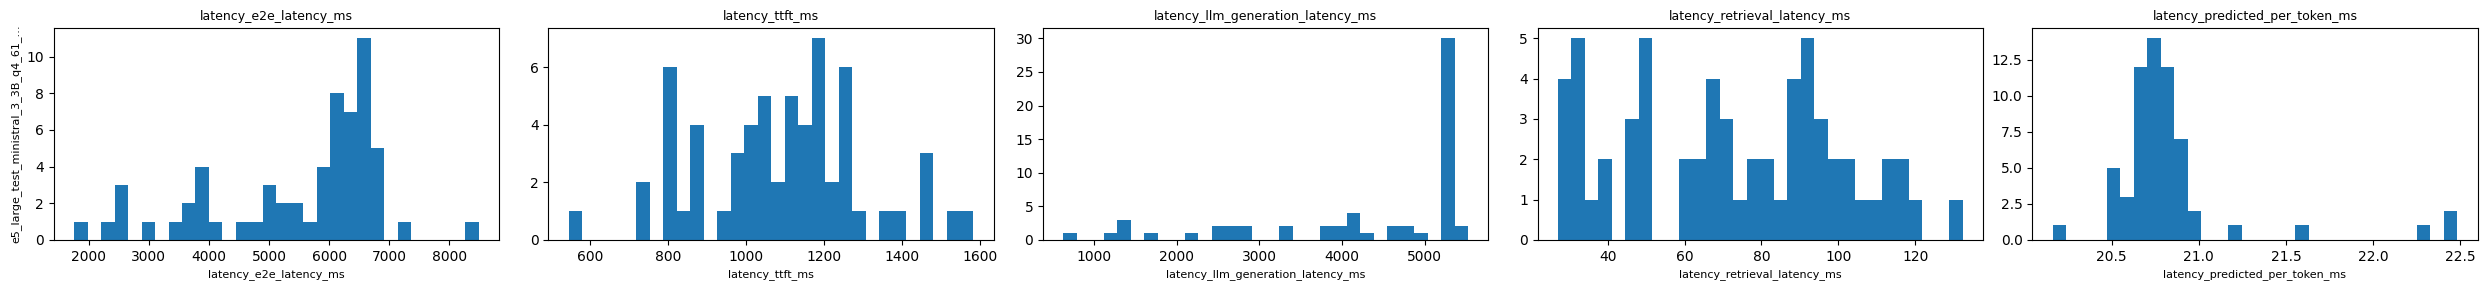

In [10]:
plot_latency_as_hist(df_single)

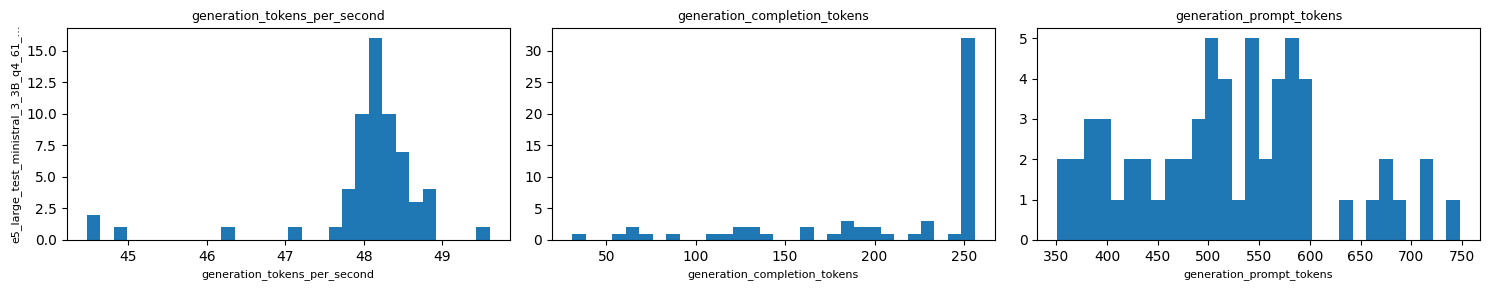

In [11]:
plot_generation_as_hist(df_single)

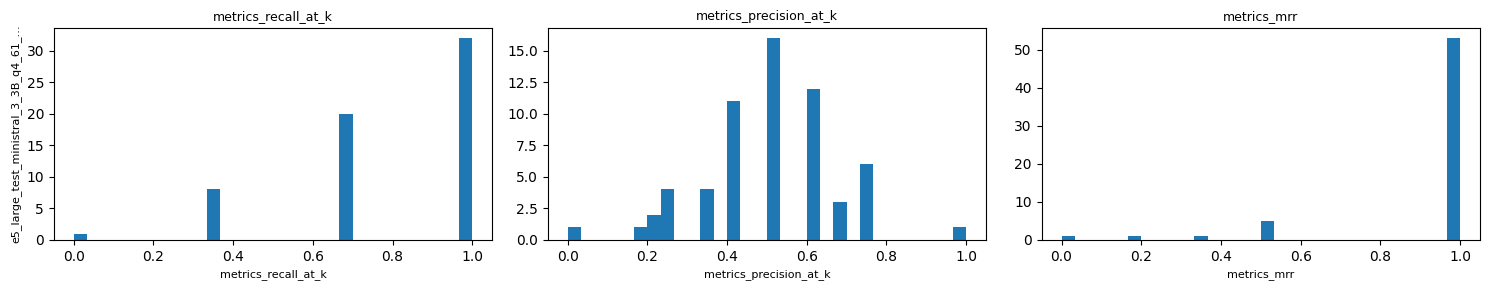

In [12]:
plot_retrieval_as_hist(df_single)

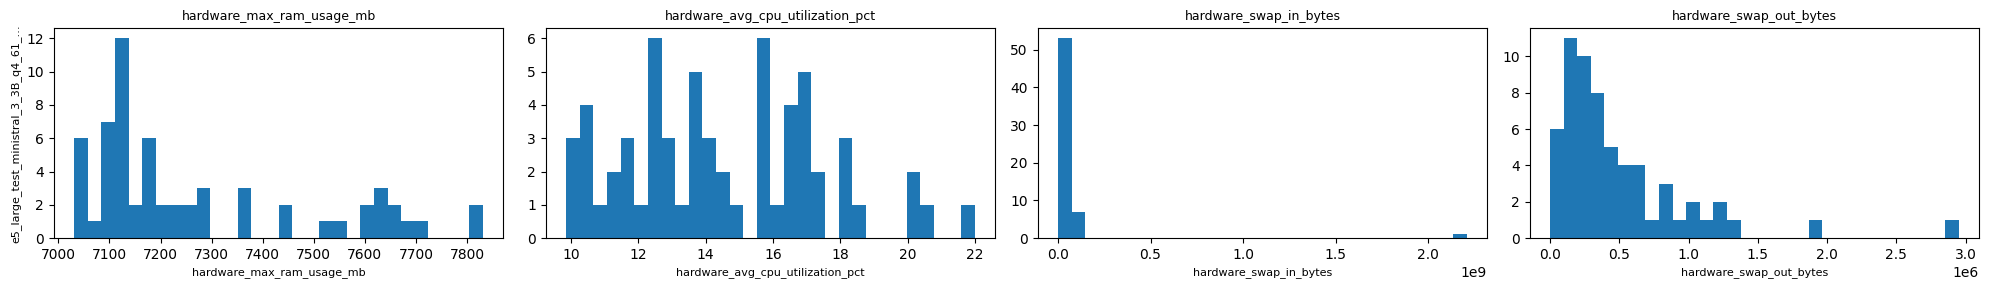

In [13]:
plot_hardware_as_hist(df_single)

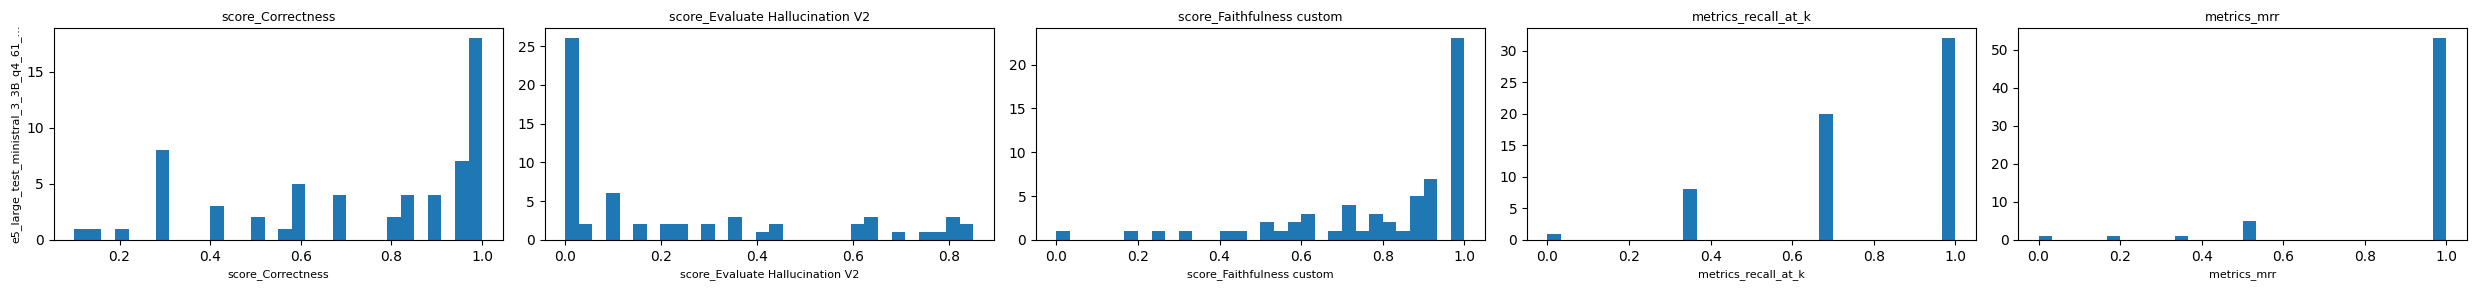

In [14]:
plot_generation_quality_as_hist(df_single)

---
# 2  Multiple Runs Analysis

Compare across different configurations (different `run_id` values). Load all files or a filtered subset below.

In [15]:
# Load multiple export files for comparison.
# Adjust the pattern to select the relevant set of runs.
df_multi = load_files(folder=EXPORT_DIR, pattern="*langfuse_export*.parquet")

run_ids = get_run_ids(df_multi)
print(f"\nRun IDs ({len(run_ids)}):")
for r in run_ids:
    print(f"  {r}")

Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_ministral_3_3B_q4_61_40085d87.parquet
Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_ministral_3_3B_q4_61_79ef3626.parquet
Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_ministral_3_3B_q5_61_23c47ab9.parquet
Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_ministral_3_3B_q5_61_f096093a.parquet
Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_ministral_3_3B_q8_61_2a62bc35.parquet
Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_ministral_3_3B_q8_61_73db2260.parquet
Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_ministral_3_8B_q4_61_5b437b29.parquet
Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_ministral_3_8B_q4_61_e4176cee.parquet
Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_ministral_3_8B_q5_61_907aac99.parquet
Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_ministral_3_8B_q5_61_d4b17c70.parquet
Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_mist

## 2.1  Mean Metrics per Run ID

In [16]:
multi_metric_cols = _numeric_metric_cols(df_multi)
df_multi.groupby("run_id")[multi_metric_cols].mean().round(3)

,latency_ms,latency_ttft_ms,latency_llm_generation_latency_ms,latency_prompt_ms,latency_predicted_ms,latency_predicted_per_token_ms,generation_prompt_tokens,generation_completion_tokens,generation_tokens_per_second,latency_retrieval_latency_ms,...,metrics_precision_at_k,metrics_mrr,latency_e2e_latency_ms,hardware_max_ram_usage_mb,hardware_avg_cpu_utilization_pct,hardware_swap_in_bytes,hardware_swap_out_bytes,score_Faithfulness custom,score_Correctness,score_Evaluate Hallucination V2
run_id,,,,,,,,,,,,,,,,,,,,,
e5_large_test_ministral_3_3B_q4_61,5587.143,1091.716,4375.980,1070.859,4375.980,20.857,520.049,209.770,47.962,76.380,...,0.492,0.918,5581.438,7337.960,13.116,5.358401e+07,488766.951,0.829,0.737,0.218
e5_large_test_ministral_3_3B_q5_61,12177.582,2459.718,9613.471,2417.400,9613.471,42.318,520.049,208.820,38.422,72.777,...,0.492,0.918,6764.420,7752.811,13.589,8.250848e+07,818461.377,0.849,0.727,0.206
e5_large_test_ministral_3_3B_q8_61,6734.180,971.319,5614.331,944.831,5614.331,26.488,520.049,211.656,37.769,92.347,...,0.492,0.918,6724.872,8521.056,13.129,8.649617e+07,614064.262,0.833,0.737,0.209
e5_large_test_ministral_3_8B_q4_61,12549.275,2590.014,9718.823,2542.915,9718.823,47.099,520.049,203.840,22.154,112.525,...,0.492,0.918,11989.076,9625.948,14.363,1.560330e+08,1358999.082,0.865,0.768,0.166
e5_large_test_ministral_3_8B_q5_61,14149.869,2859.436,11001.750,2805.051,11001.750,54.386,520.049,201.943,18.390,113.976,...,0.492,0.918,14125.878,10231.265,14.732,3.085018e+08,1740061.377,0.876,0.759,0.159
e5_large_test_mistral_7B_0_3_iq3_61,8861.336,2682.820,6060.954,2644.957,6060.954,37.863,563.164,159.541,26.413,81.315,...,0.492,0.918,8854.823,8623.230,10.141,1.003478e+08,503875.148,0.829,0.621,0.280
e5_large_test_mistral_7B_0_3_q3l_61,9060.926,2793.627,6105.506,2746.834,6105.506,46.793,563.164,129.992,21.377,116.419,...,0.492,0.918,9048.967,8618.464,14.703,1.369790e+08,992172.066,0.880,0.736,0.136
e5_large_test_mistral_7B_0_3_q4_61,8017.385,2563.242,5298.887,2524.760,5298.887,38.482,563.164,137.074,25.991,111.104,...,0.492,0.918,8007.686,8948.442,12.109,1.050404e+08,662074.754,0.899,0.698,0.137
e5_large_test_mistral_7B_0_3_q8_61,8889.254,2277.682,6235.793,2230.254,6235.793,47.429,563.164,131.131,21.092,119.358,...,0.492,0.918,8870.284,11179.103,14.879,2.845847e+08,673355.541,0.901,0.717,0.134


## 2.2  Boxplots by Run ID

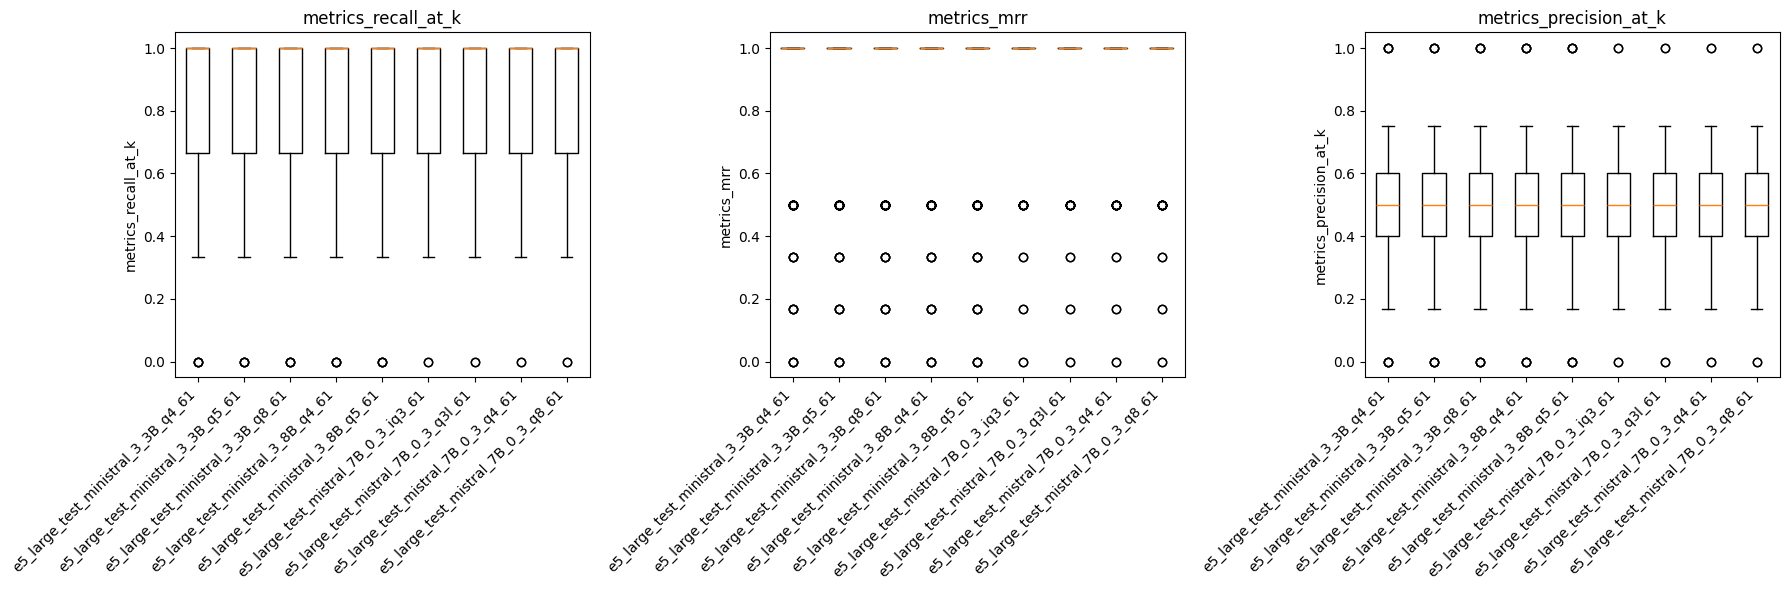

In [17]:
# Optional: set explicit order for run_ids on the x axis
run_order = None  # or: run_order = ["run_a", "run_b", ...]

plot_boxplots(df_multi, ["metrics_recall_at_k", "metrics_mrr", "metrics_precision_at_k"],
              group_by="run_id", group_order=run_order, figsize=(18, 6))

## 2.3  Lines Across Sessions / Run IDs

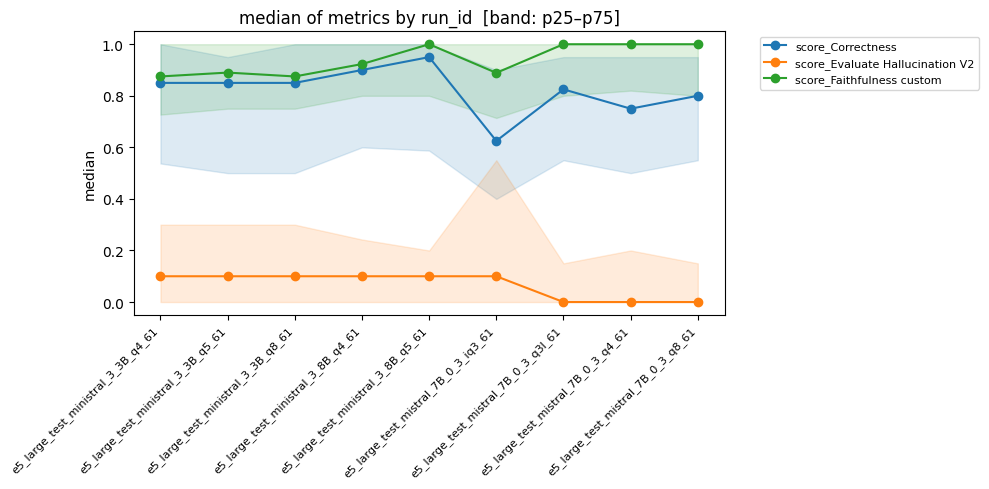

In [18]:
score_cols = _present(df_multi, ["score_Correctness", "score_Context Recall",
                                  "score_Evaluate Hallucination V2", "score_Faithfulness custom"])
plot_stats_multi_line(df_multi, score_cols,
                      group_by="run_id", group_order=run_order, stat="median", show_band=True)

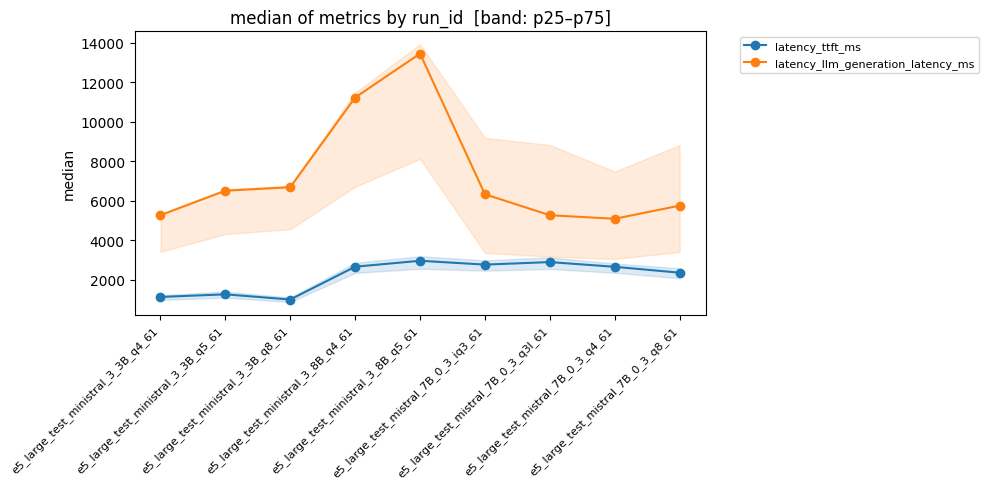

In [19]:
plot_stats_multi_line(df_multi,
                      _present(df_multi, ["latency_ttft_ms", "latency_llm_generation_latency_ms"]),
                      group_by="run_id", group_order=run_order, stat="median", show_band=True)

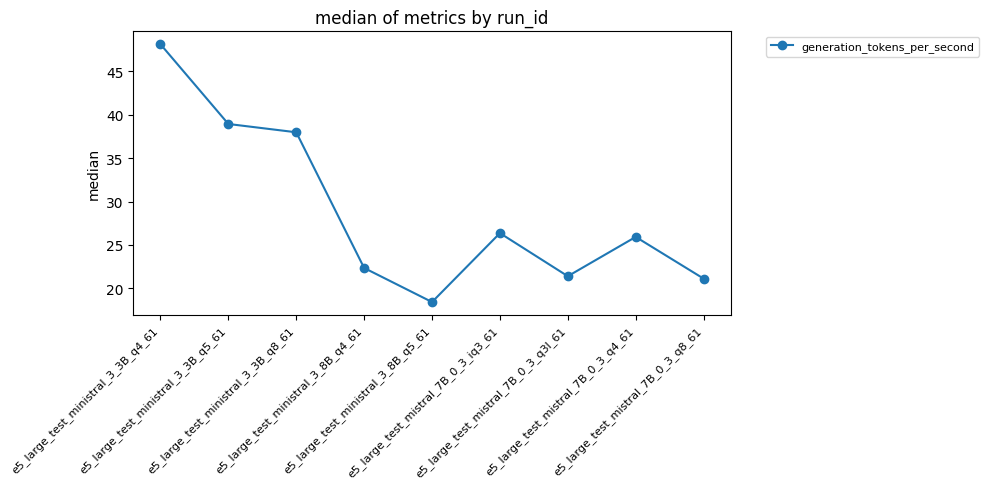

In [68]:
plot_stats_multi_line(df_multi,
                      _present(df_multi, ["generation_tokens_per_second"]),
                      group_by="run_id", group_order=run_order, stat="median")

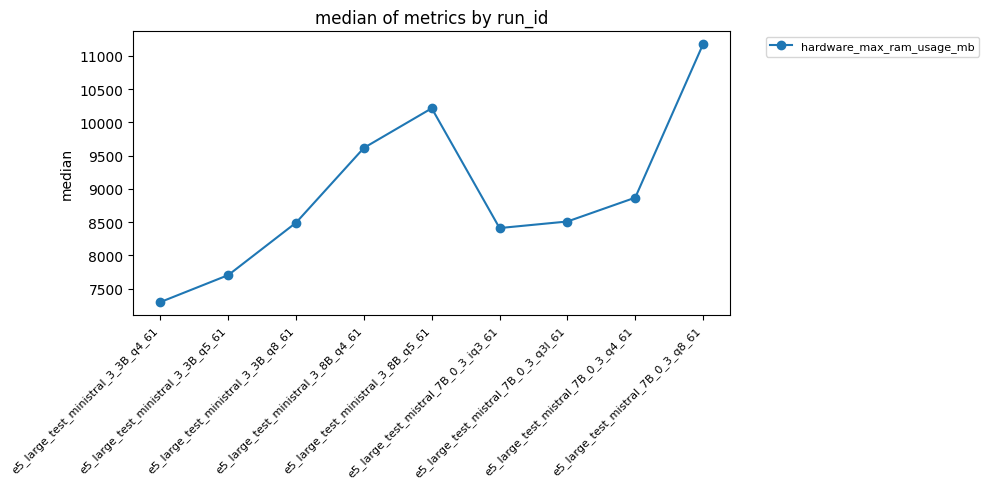

In [69]:
plot_stats_multi_line(df_multi,
                      _present(df_multi, ["hardware_max_ram_usage_mb"]),
                      group_by="run_id", group_order=run_order, stat="median")

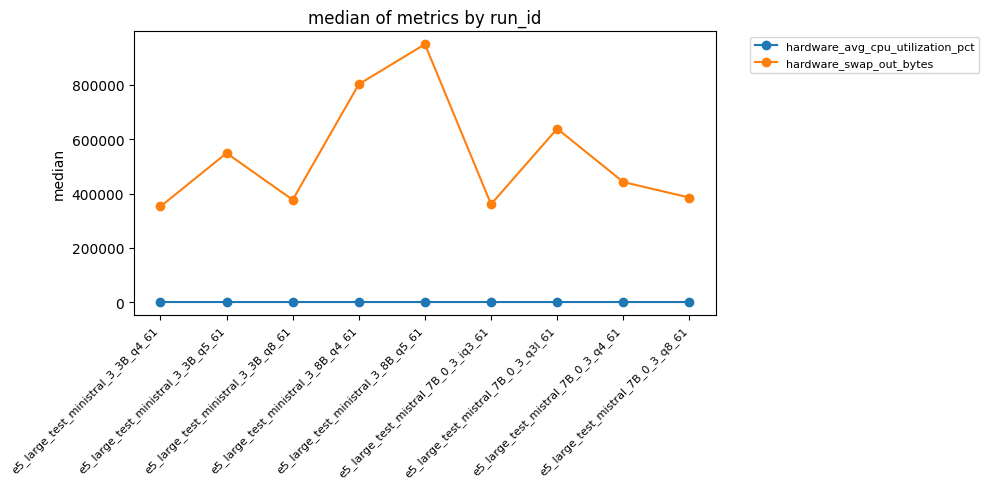

In [71]:
plot_stats_multi_line(df_multi,
                      _present(df_multi, ["hardware_avg_cpu_utilization_pct", "hardware_swap_out_bytes"]),
                      group_by="run_id", group_order=run_order, stat="median")

## 2.3  Histogram Grids by Run ID

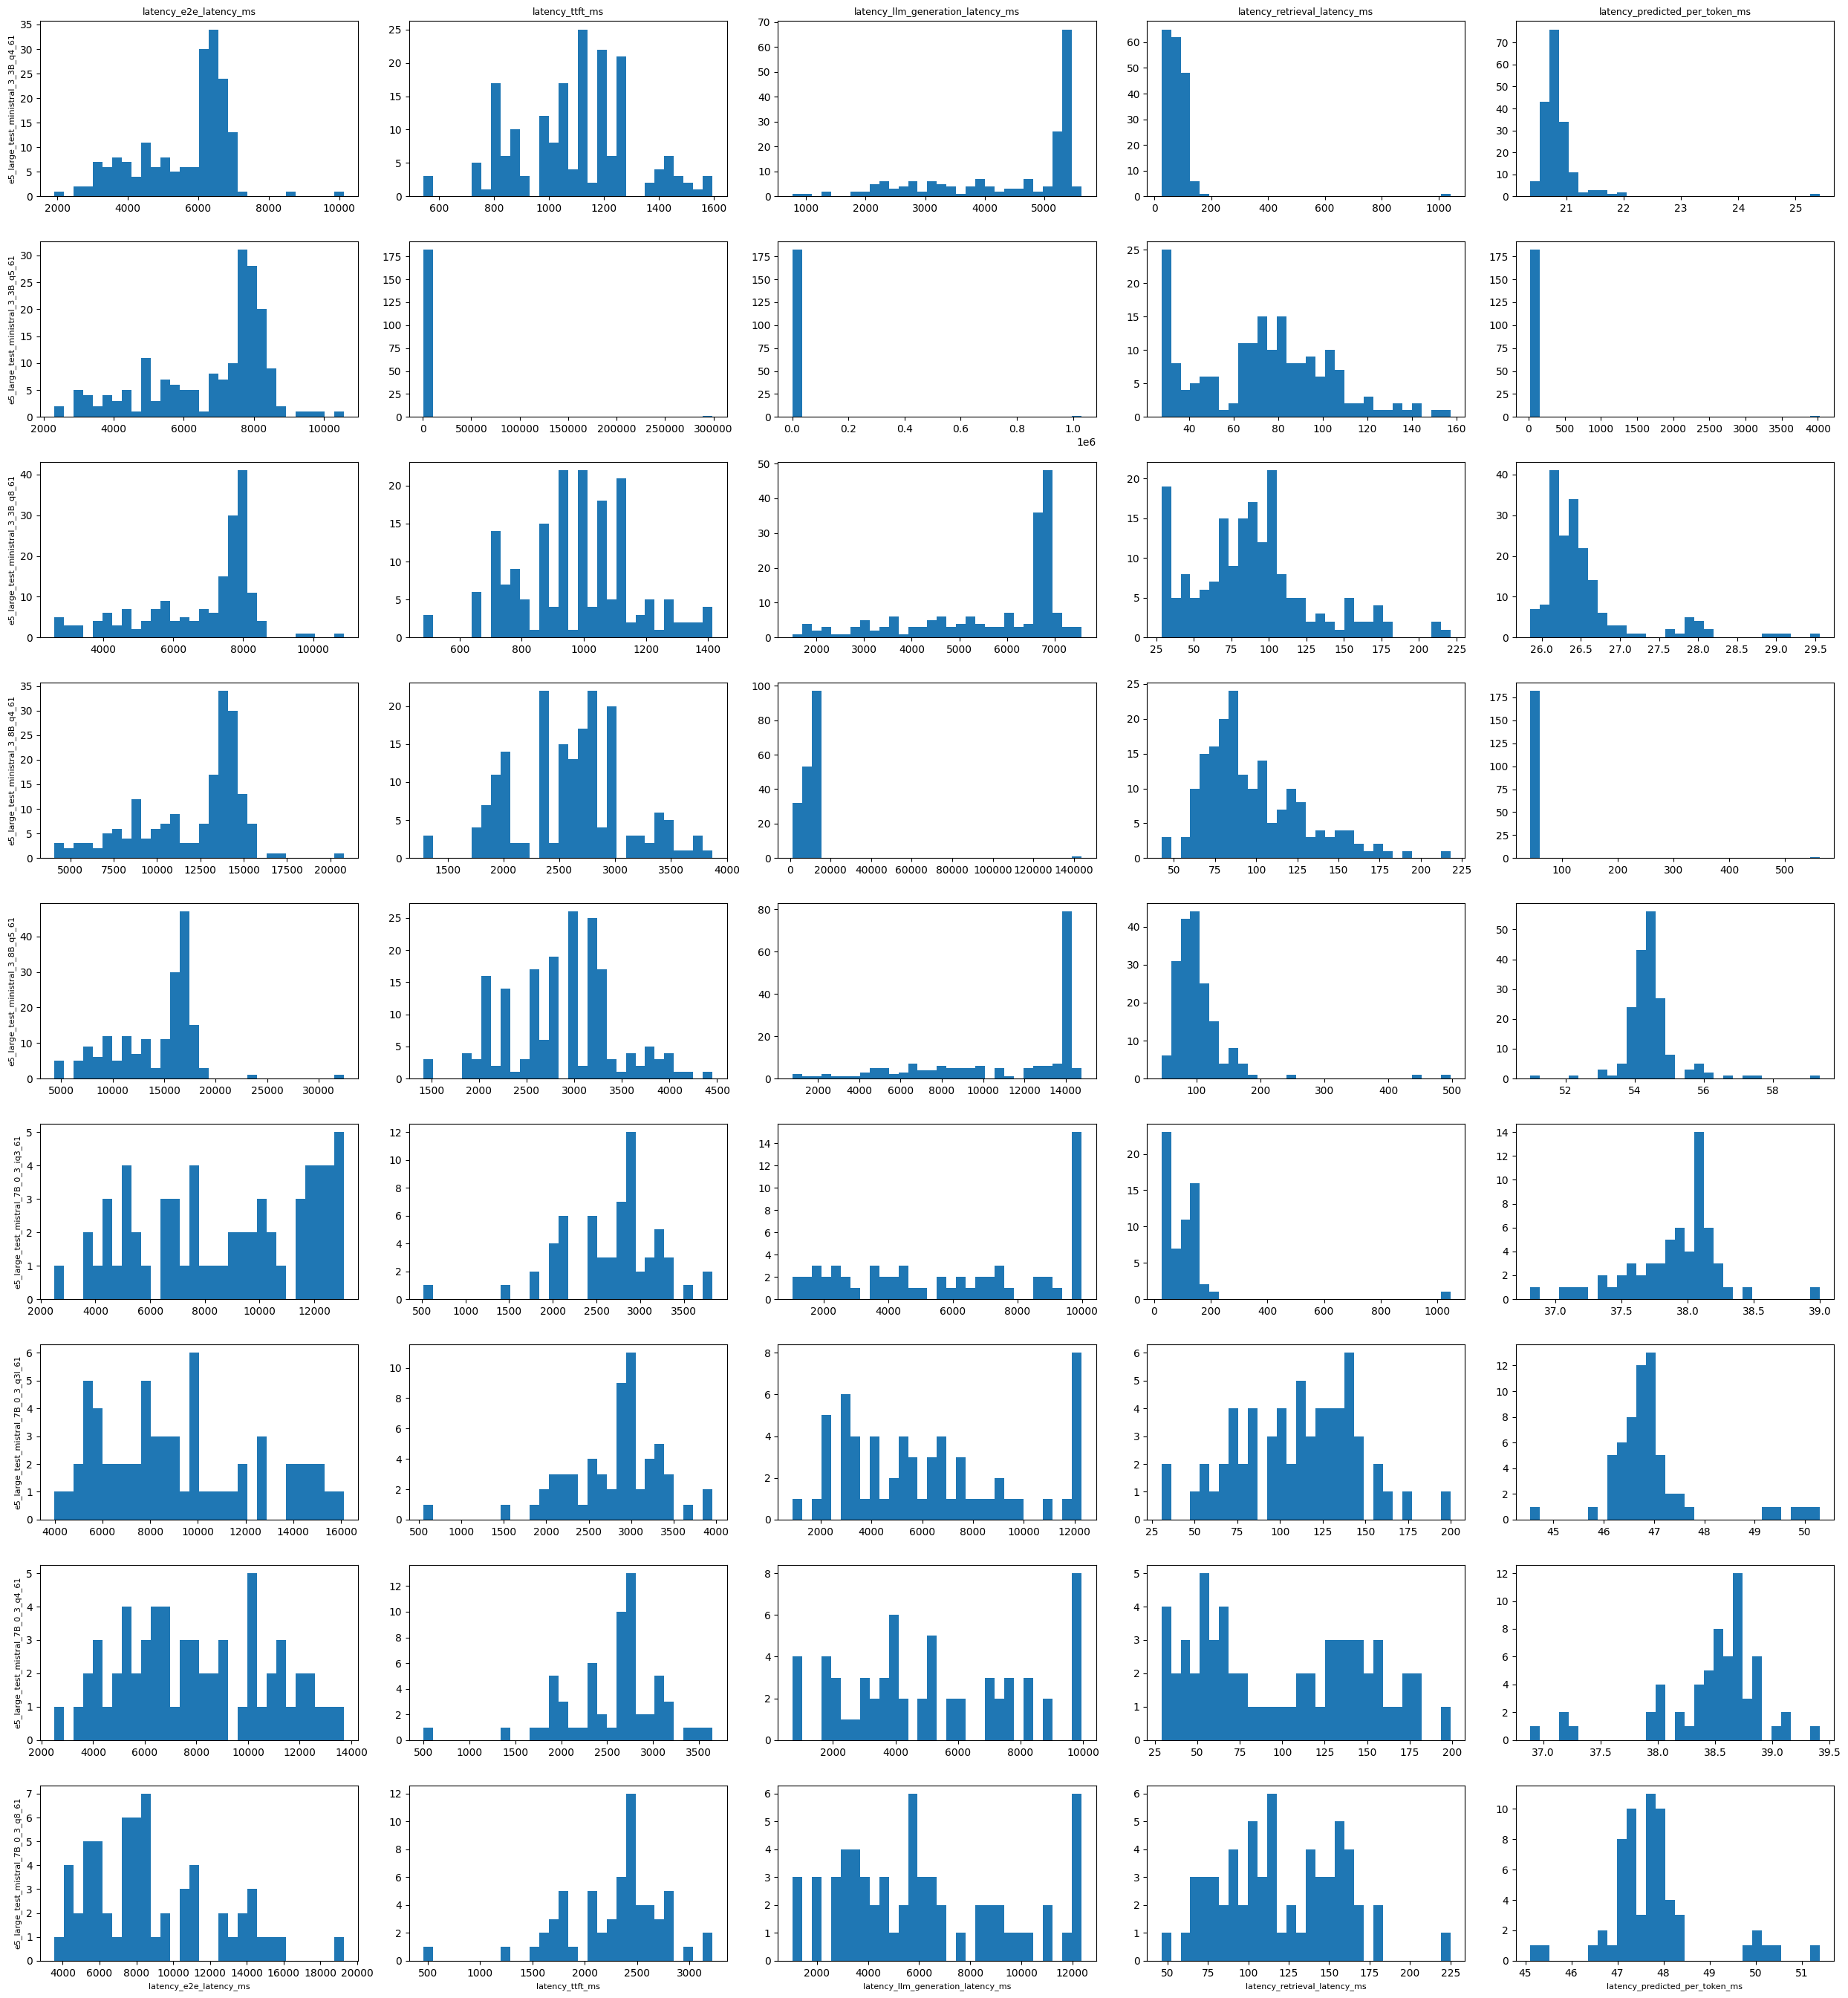

In [21]:
plot_latency_as_hist(df_multi, group_by="run_id", group_order=run_order)

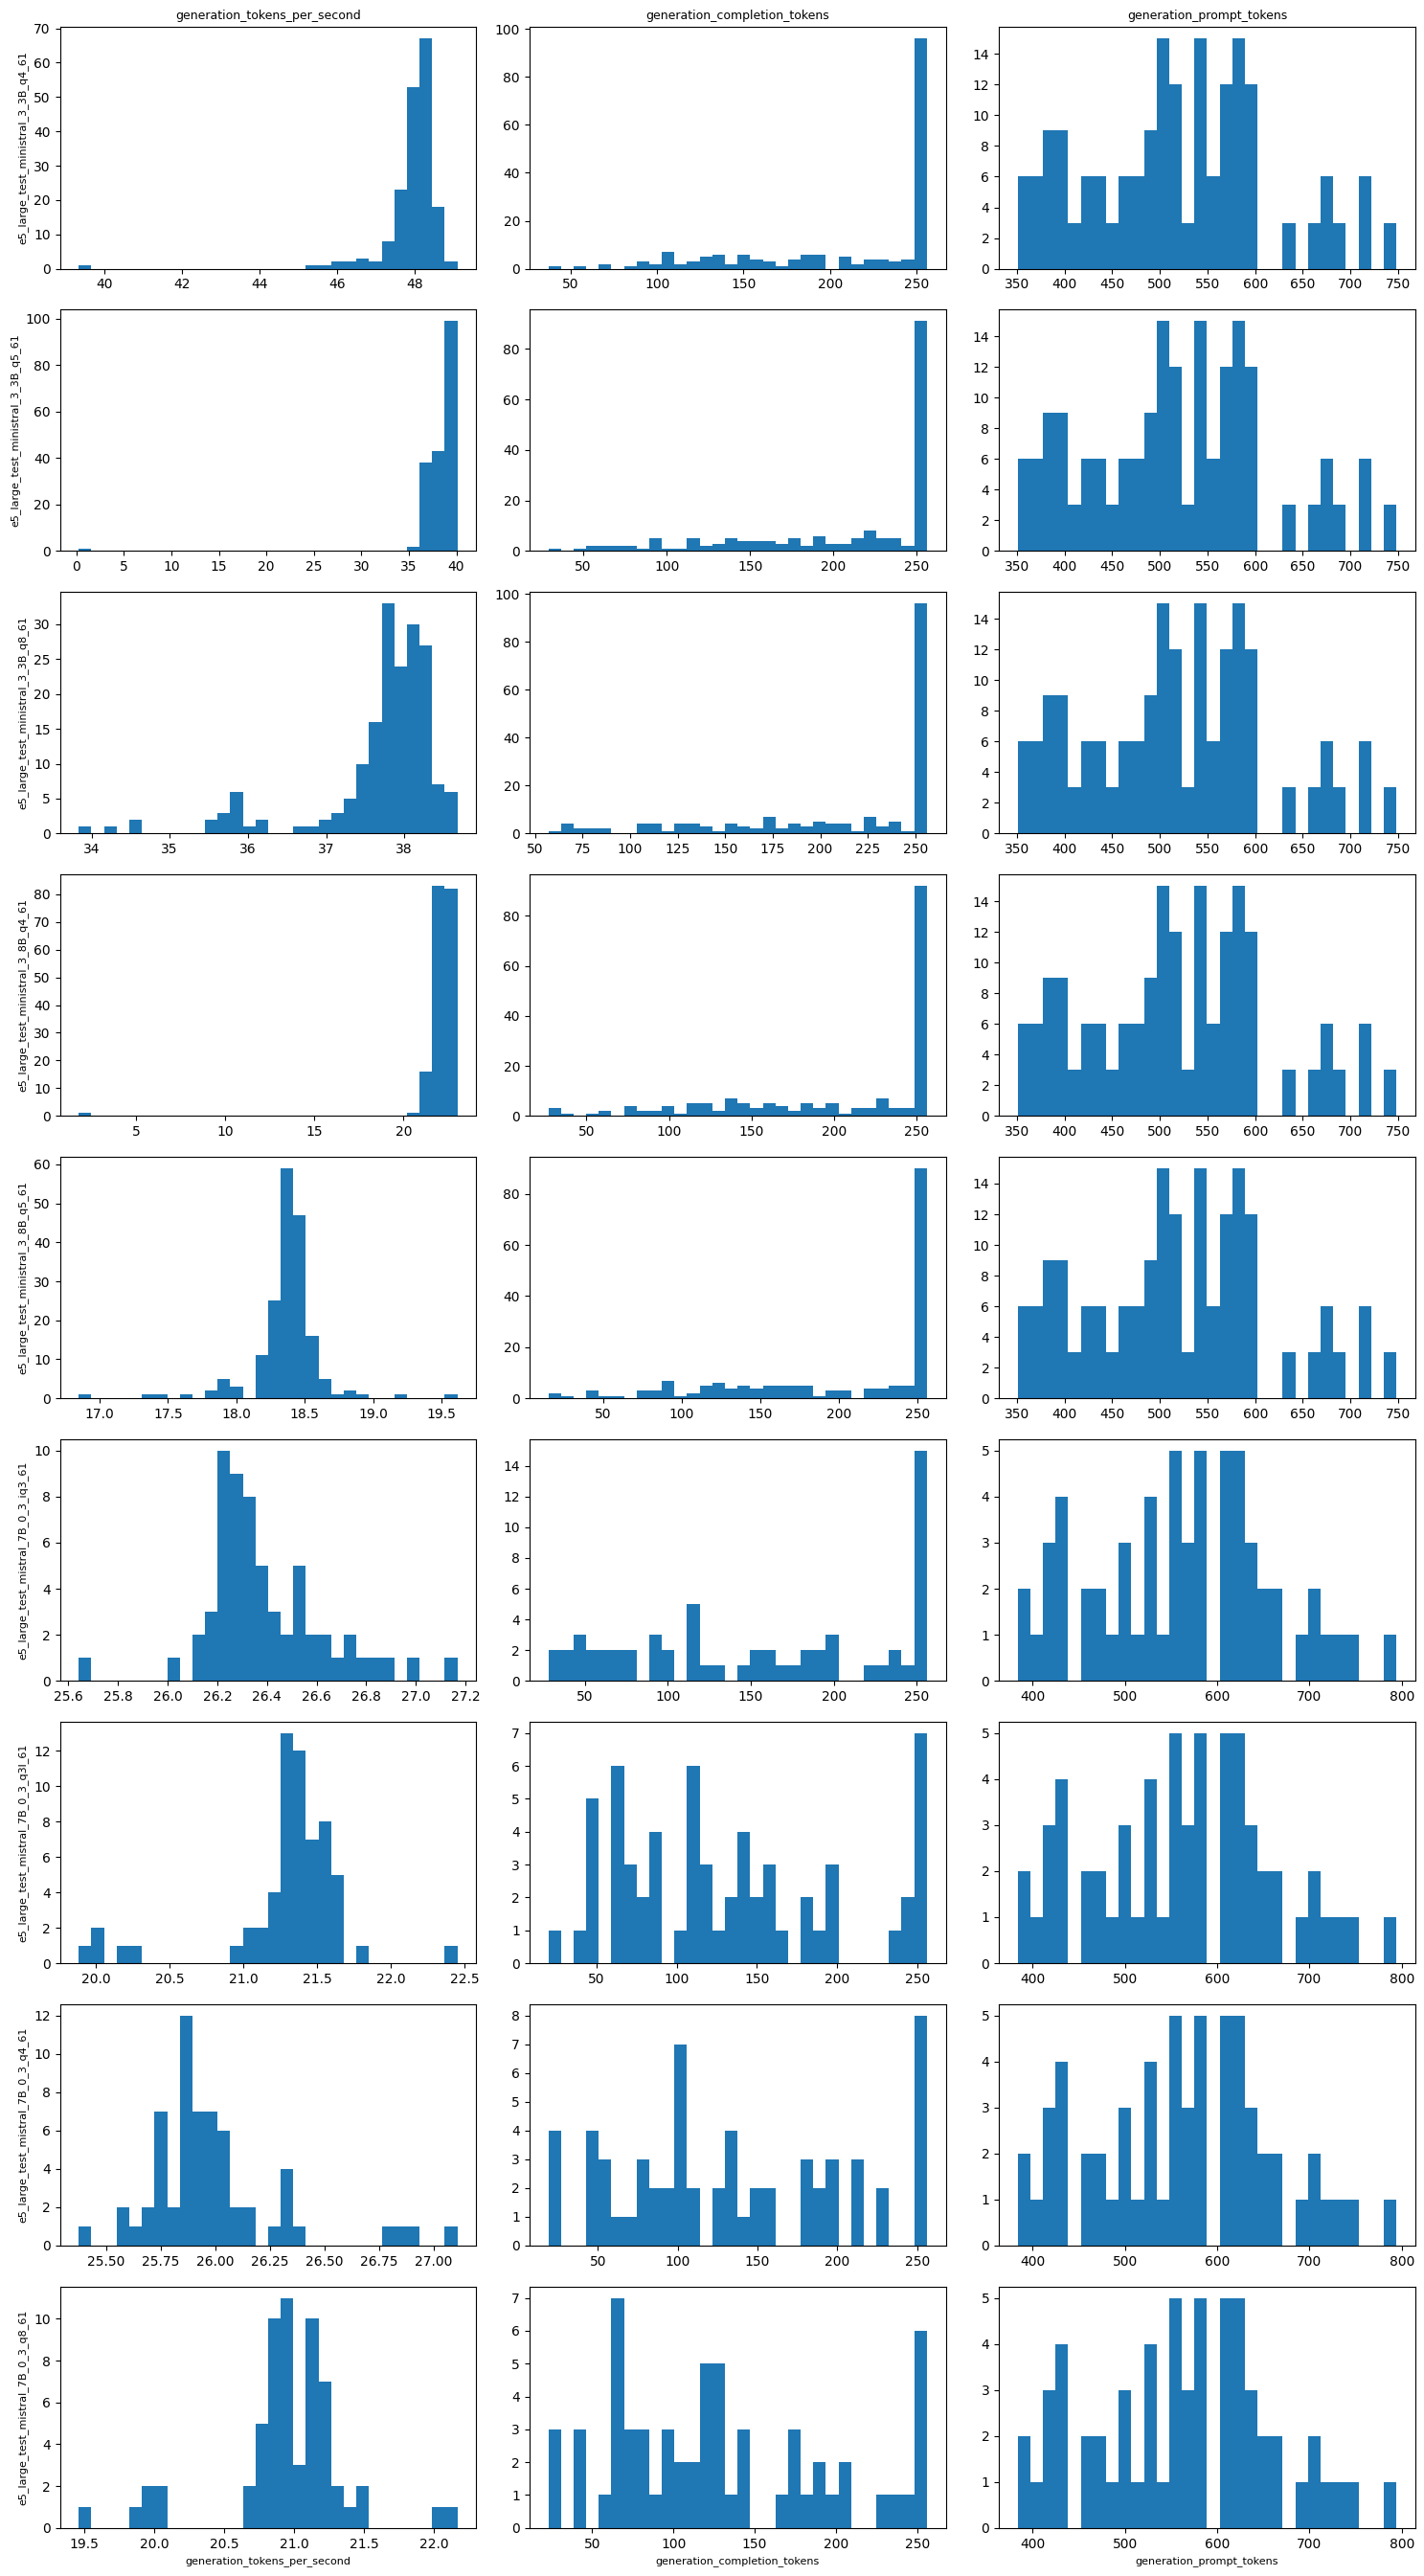

In [22]:
plot_generation_as_hist(df_multi, group_by="run_id", group_order=run_order)

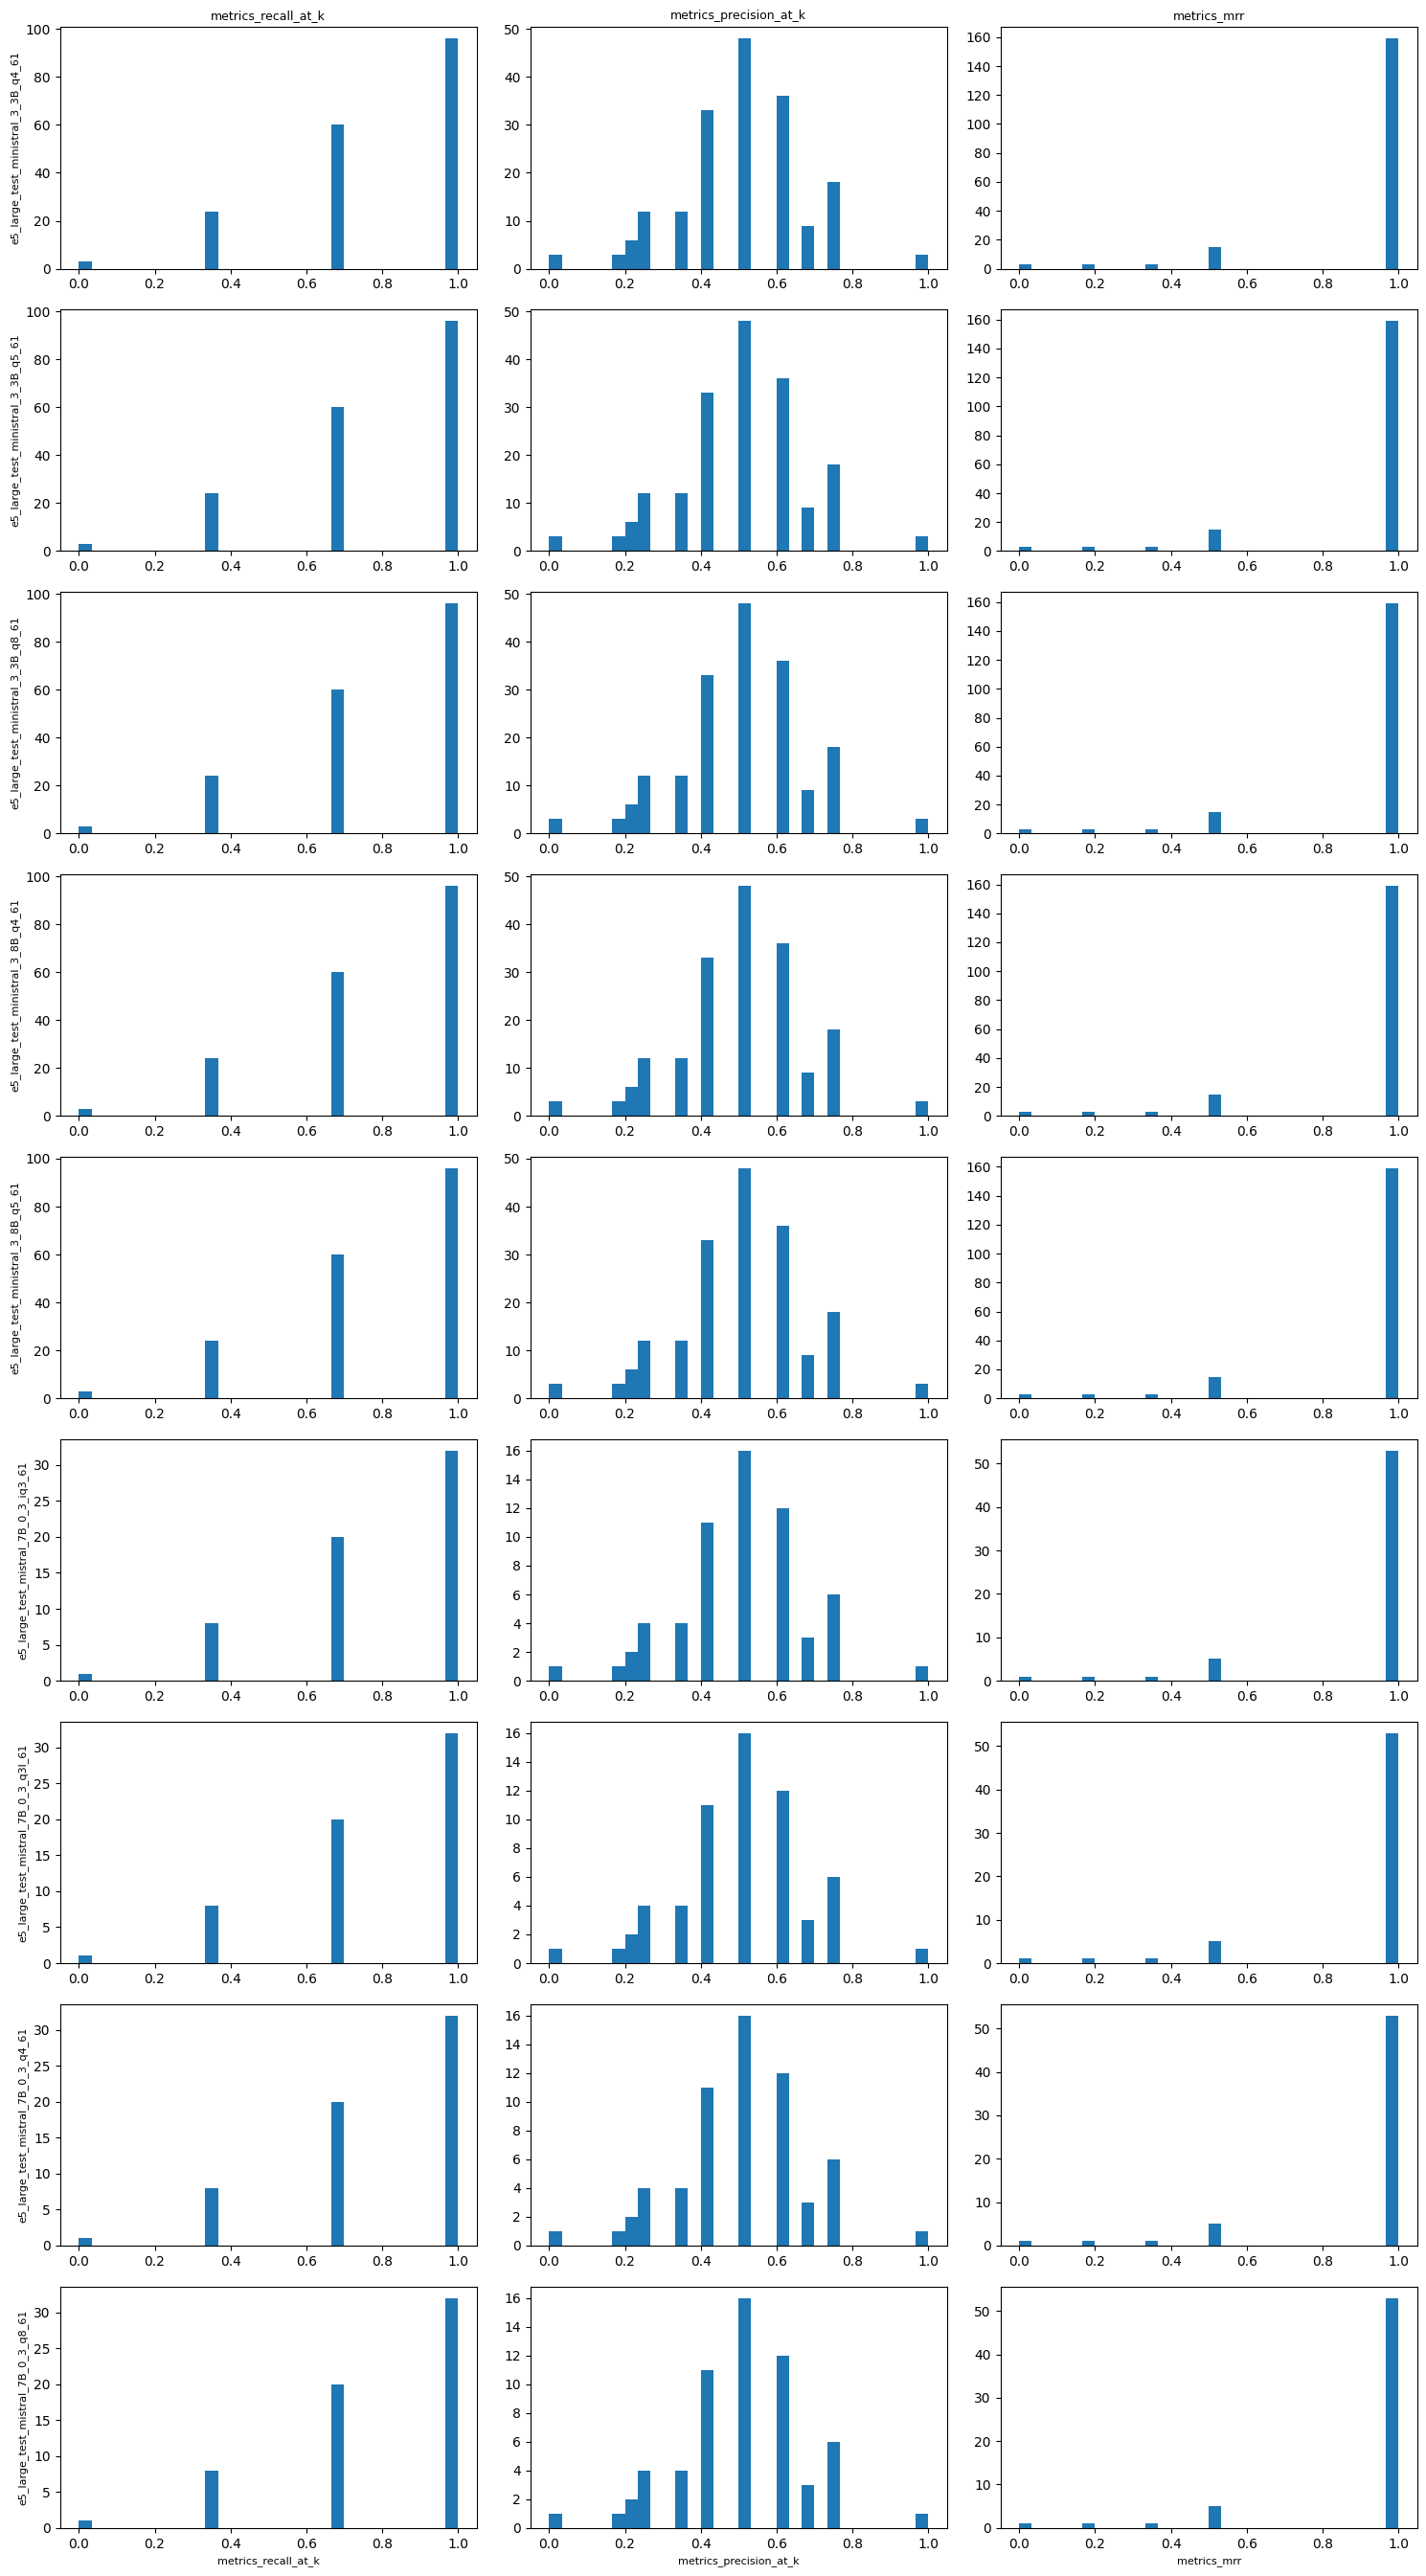

In [23]:
plot_retrieval_as_hist(df_multi, group_by="run_id", group_order=run_order)

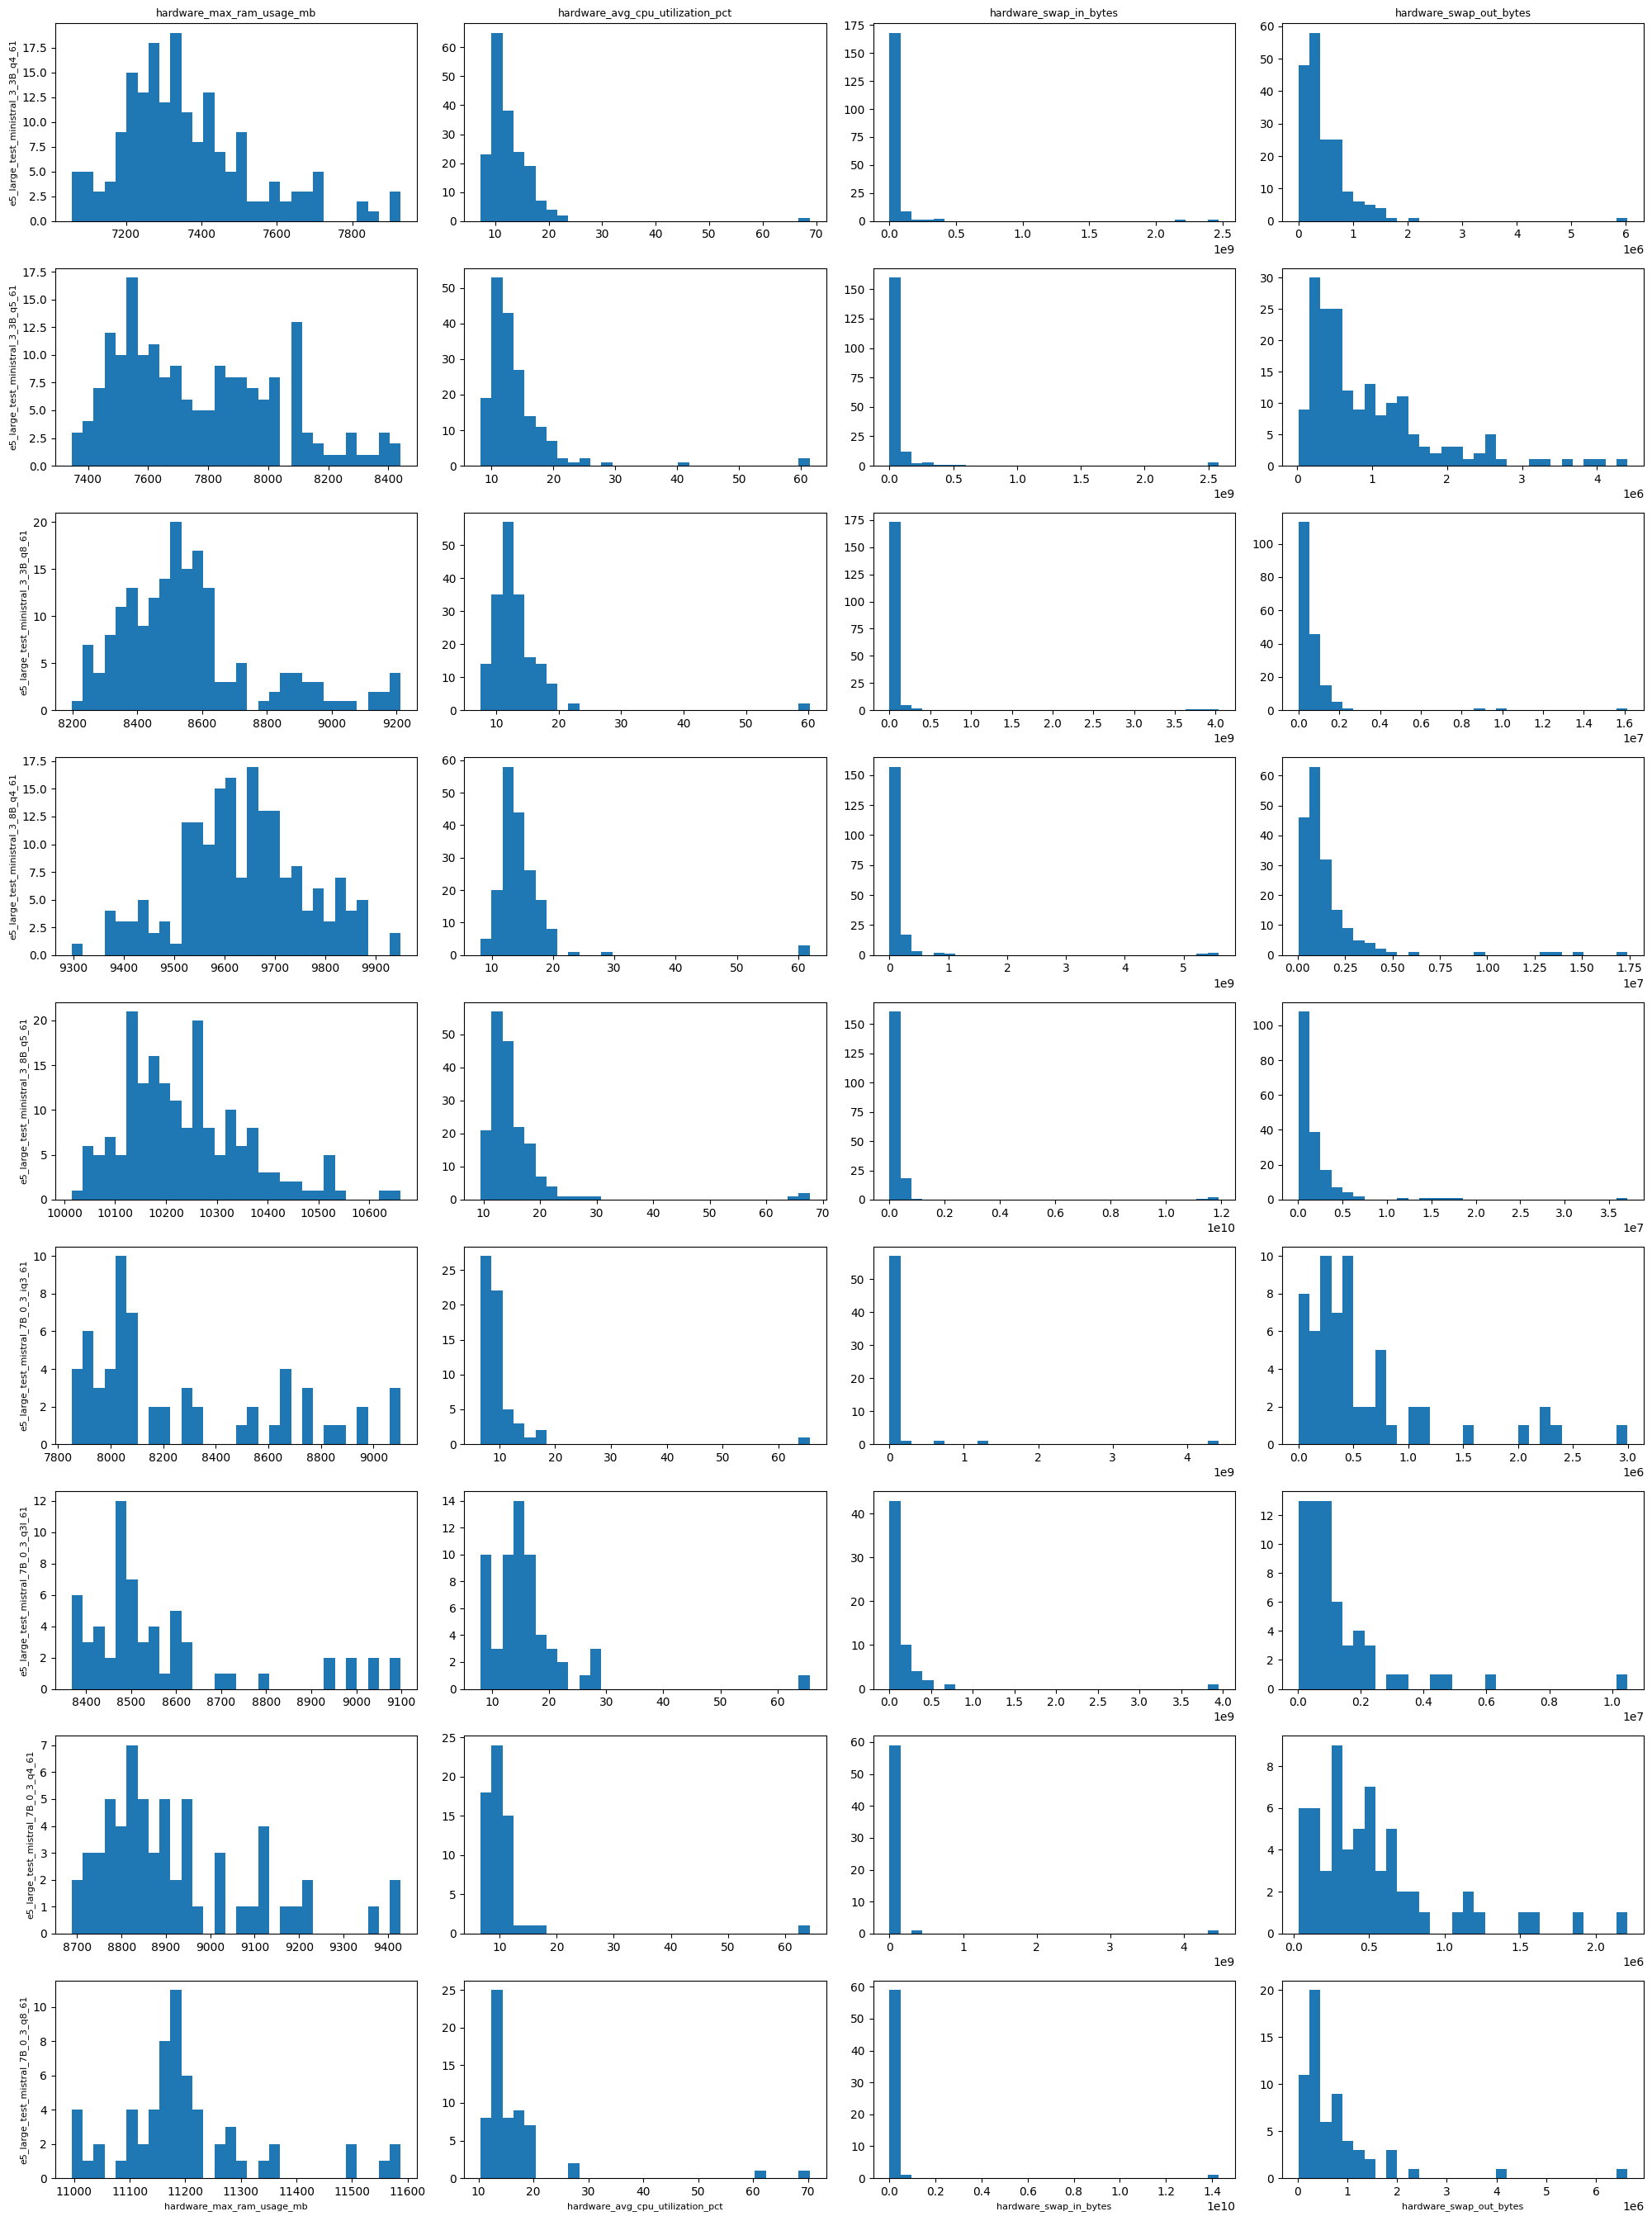

In [24]:
plot_hardware_as_hist(df_multi, group_by="run_id", group_order=run_order)

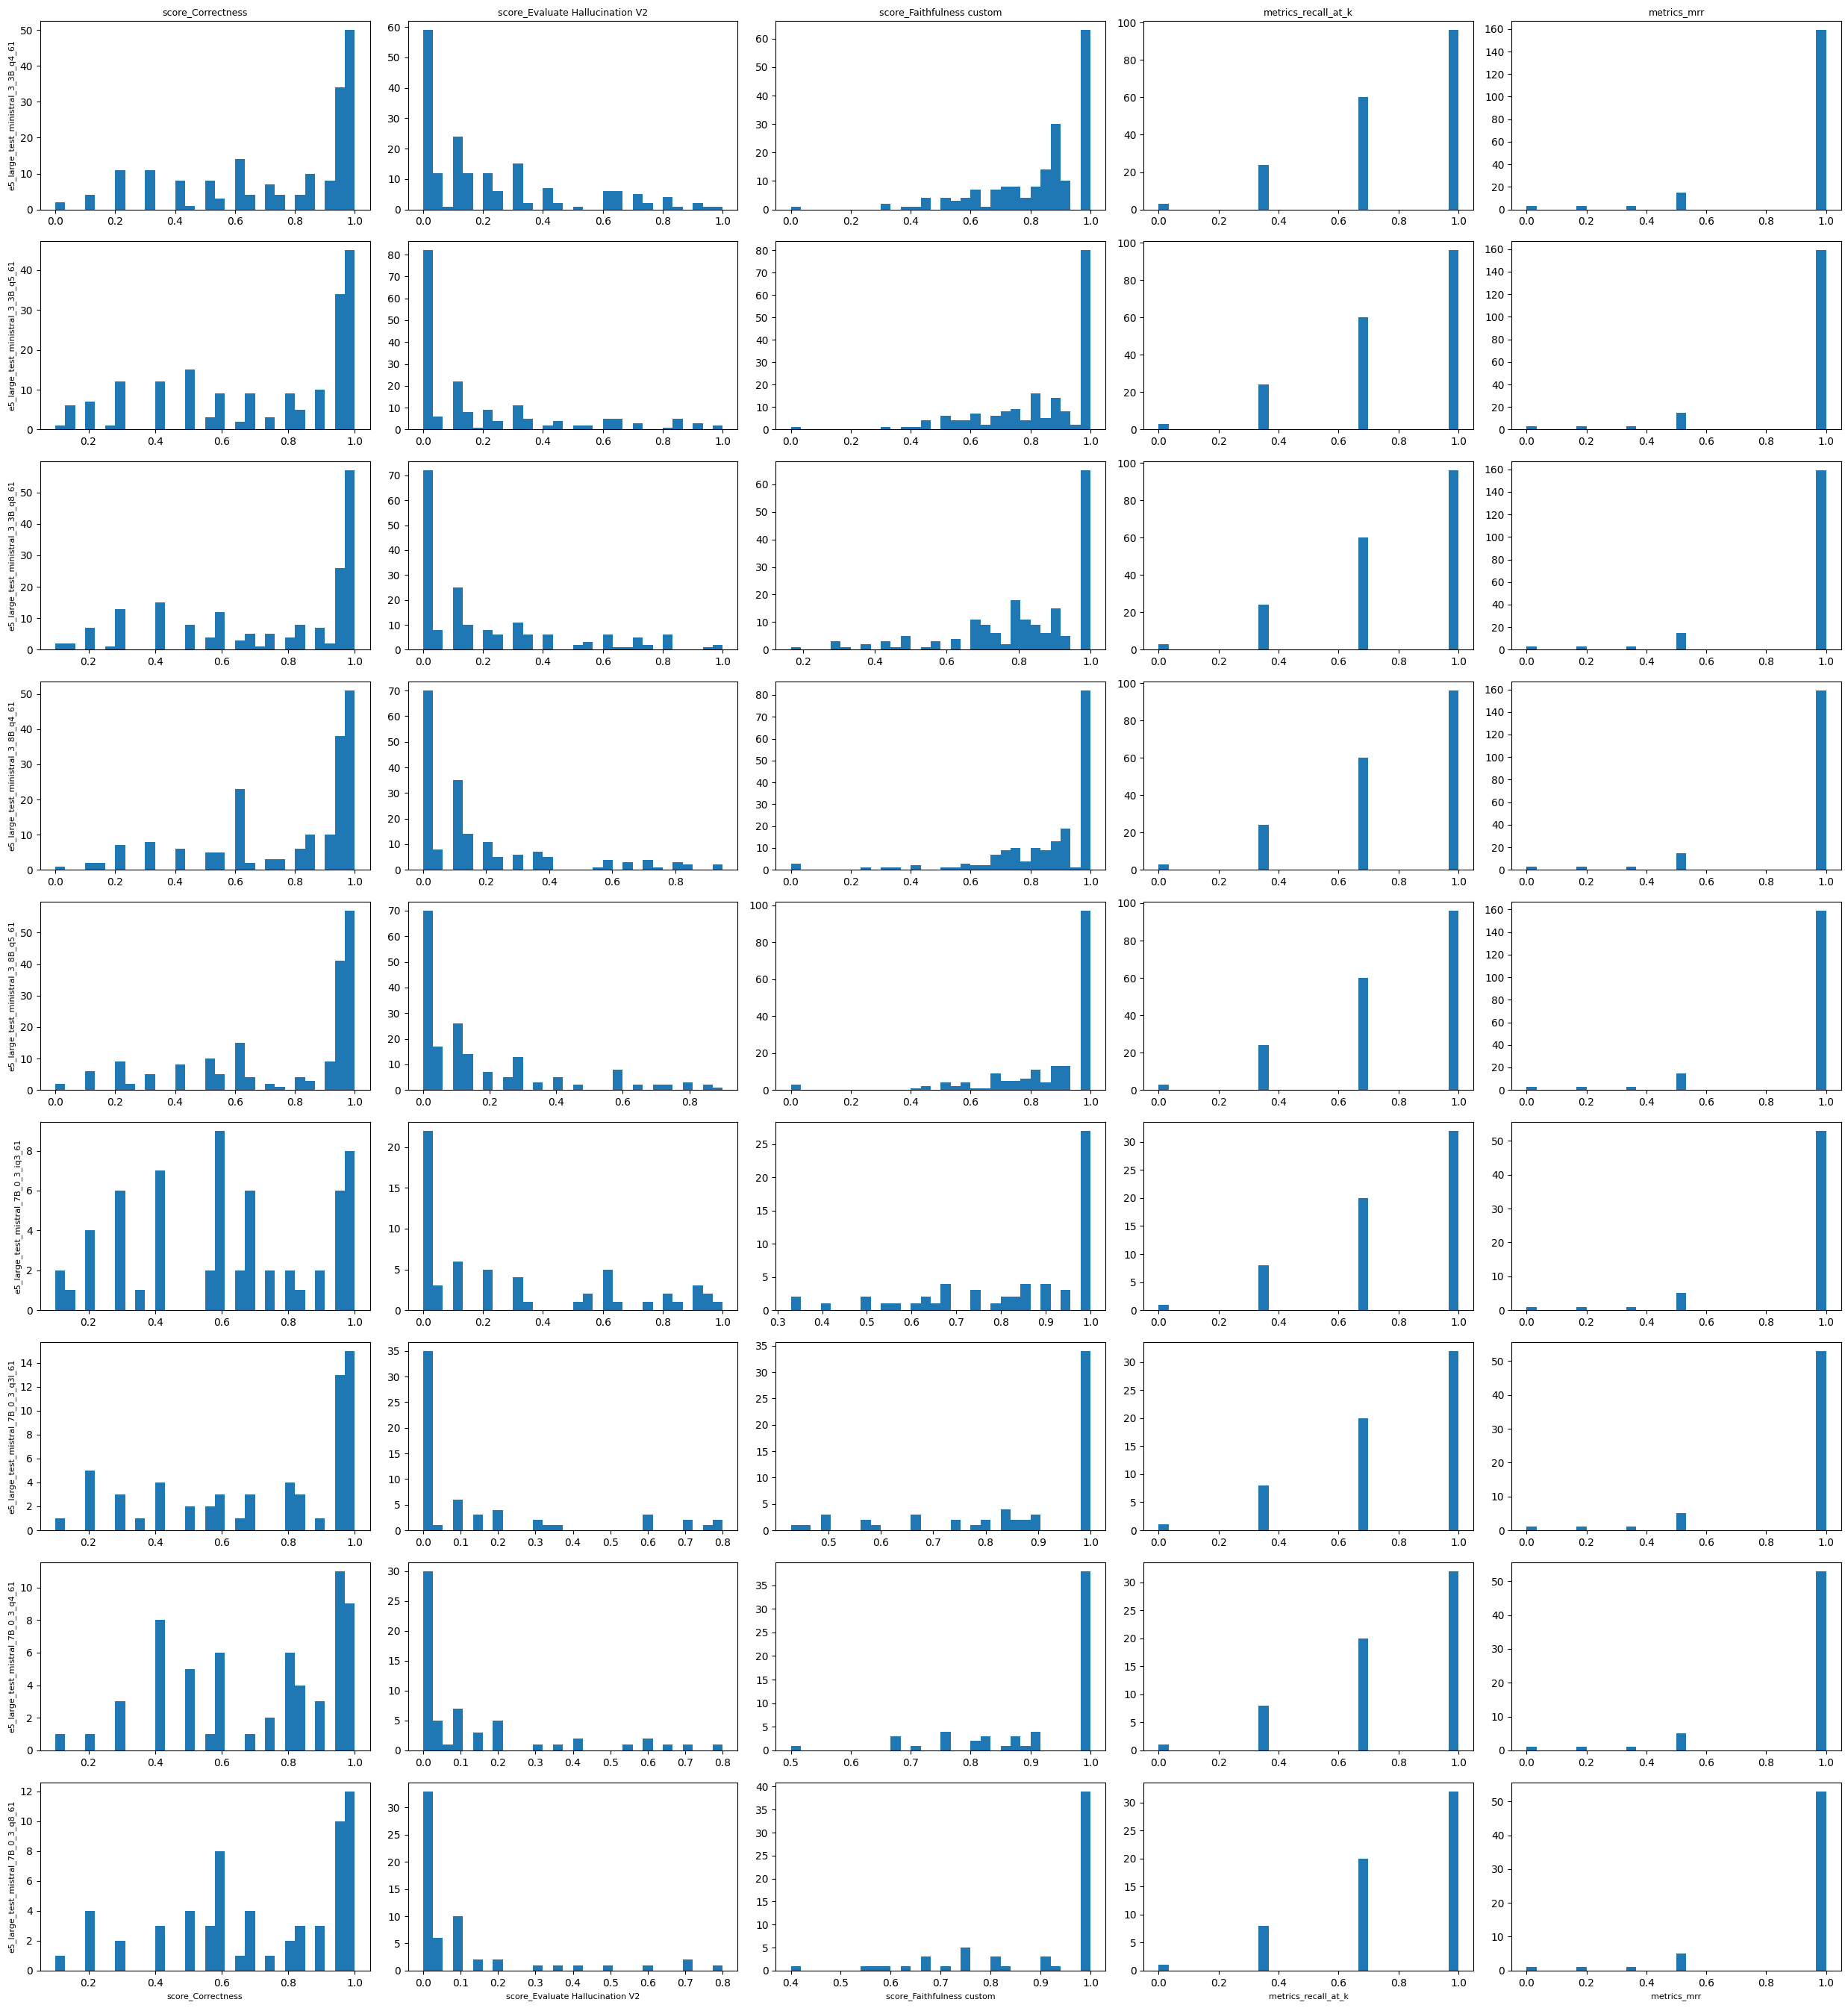

In [25]:
plot_generation_quality_as_hist(df_multi, group_by="run_id", group_order=run_order)

## 2.4  Scatter: Two Metrics by Run ID

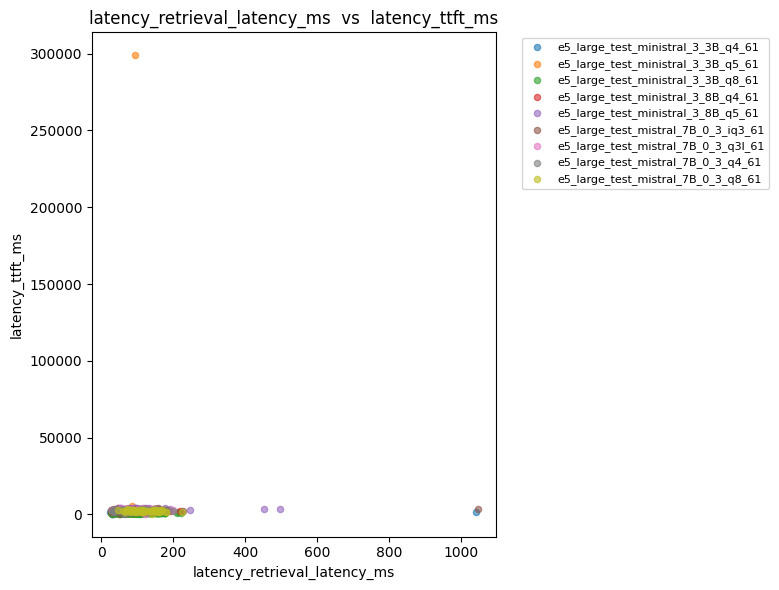

In [26]:
plot_scatter_two_metrics(
    df_multi, "latency_retrieval_latency_ms", "latency_ttft_ms",
    group_by="run_id", group_order=run_order,
)

---
# 3  Stability Analysis — Repeated Sessions of One Run ID

Multiple sessions (files) that share the same `run_id` let us assess run-to-run stability.
The `session_id` is the x-axis; one subplot per metric.

In [73]:
# Select the run_id to analyse for stability
STABILITY_RUN_ID = get_run_ids(df_multi)[0]  # replace with a string literal
STABILITY_RUN_ID = "e5_large_test_mistral_7B_0_3_q4_61"

df_stable = df_multi[df_multi["run_id"] == STABILITY_RUN_ID].copy()
stable_sessions = get_session_ids(df_stable)

print(f"Run ID:   {STABILITY_RUN_ID}")
print(f"Sessions ({len(stable_sessions)}):")
for s in stable_sessions:
    print(f"  {s}")

Run ID:   e5_large_test_mistral_7B_0_3_q4_61
Sessions (2):
  e5_large_test_mistral_7B_0_3_q4_61_0c1b3b67
  e5_large_test_mistral_7B_0_3_q4_61_28663353


## 3.1  Boxplots — Session ID as x-axis

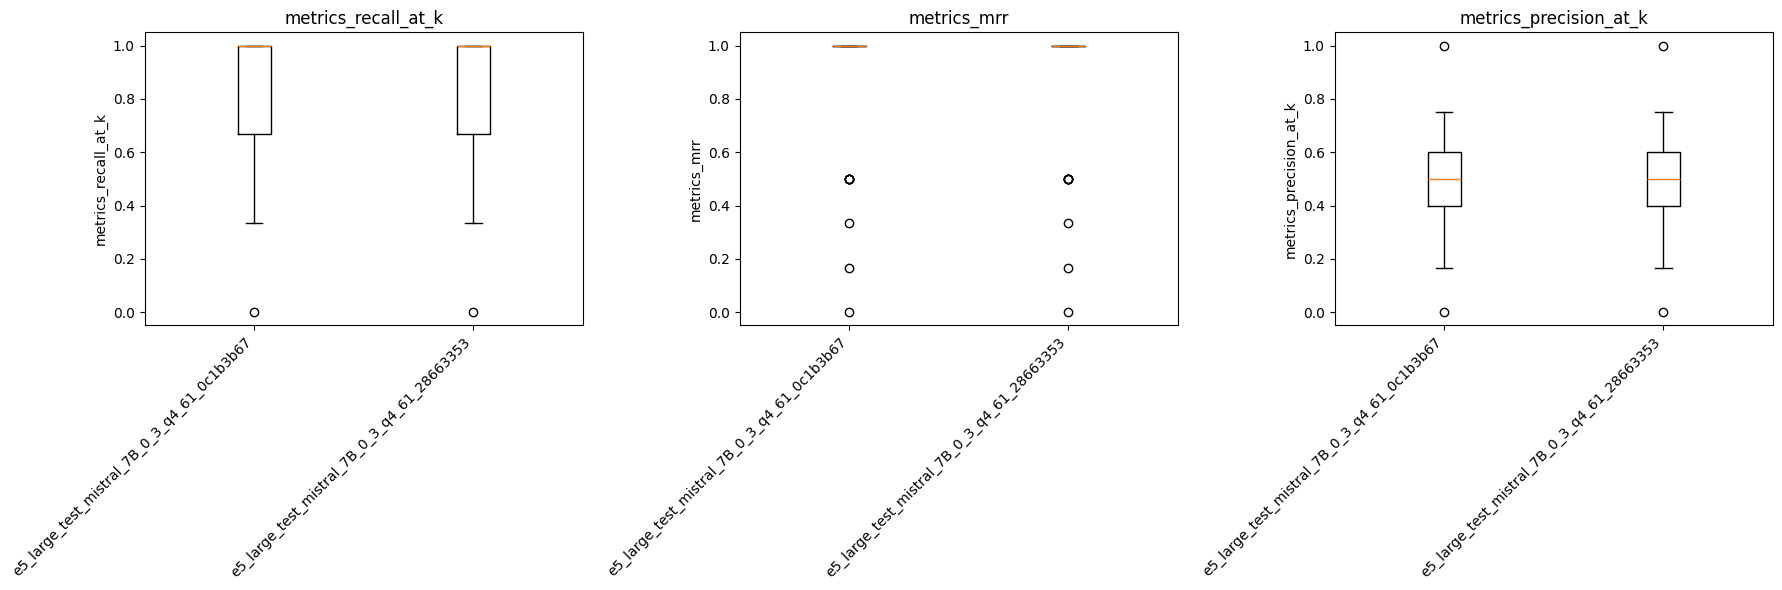

In [74]:
plot_boxplots(df_stable, ["metrics_recall_at_k", "metrics_mrr", "metrics_precision_at_k"],
              group_by="session_id", group_order=stable_sessions, figsize=(18, 6))

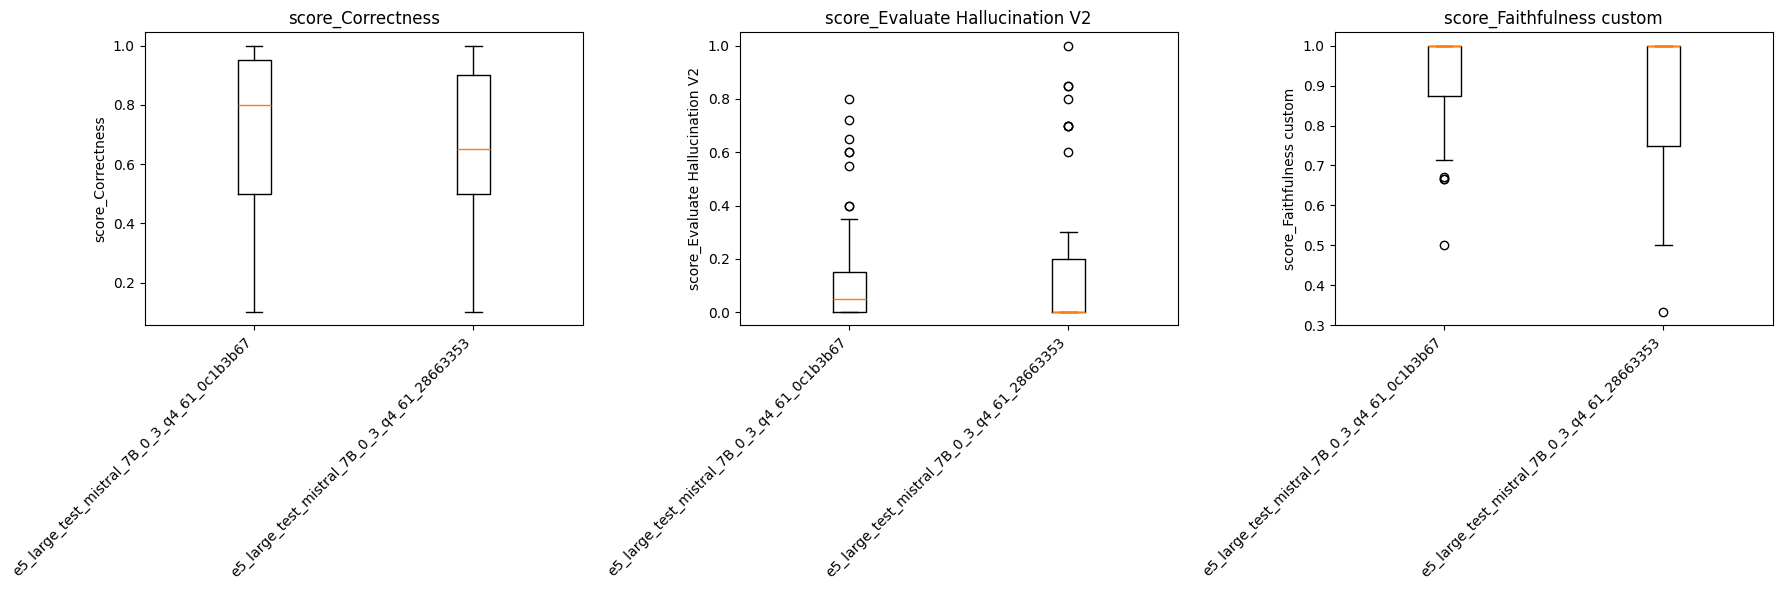

In [76]:
plot_boxplots(df_stable, ["score_Correctness", "score_Evaluate Hallucination V2", "score_Faithfulness custom"],
              group_by="session_id", group_order=stable_sessions, figsize=(18, 6))

## 3.2  Histogram Grids — Sessions as rows

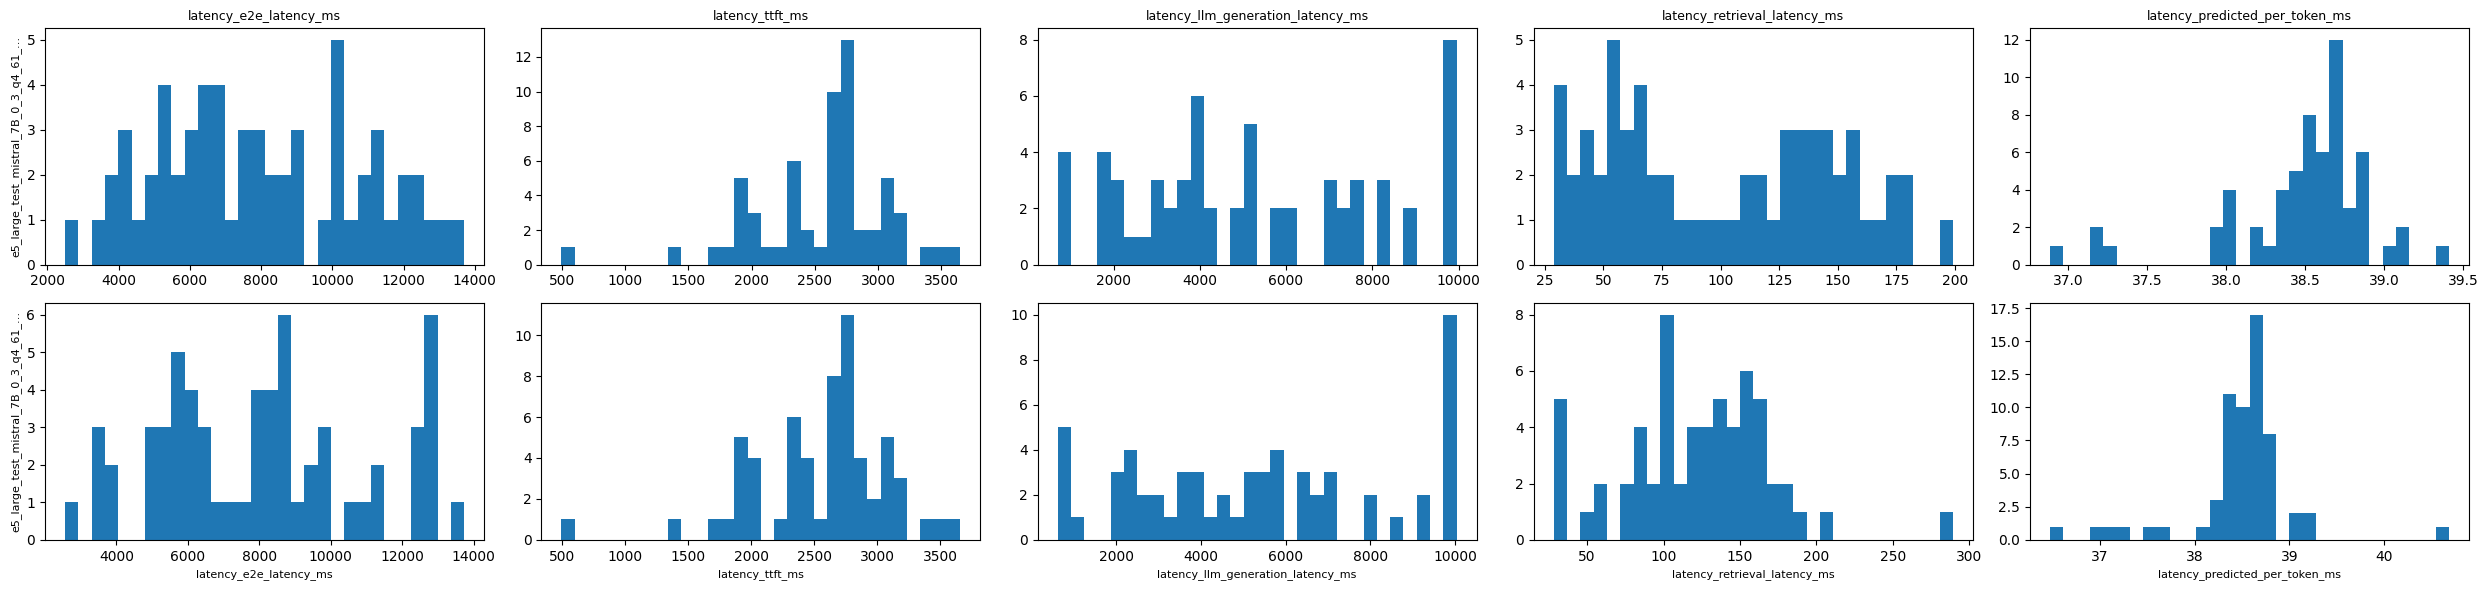

In [77]:
plot_latency_as_hist(df_stable, group_by="session_id", group_order=stable_sessions)

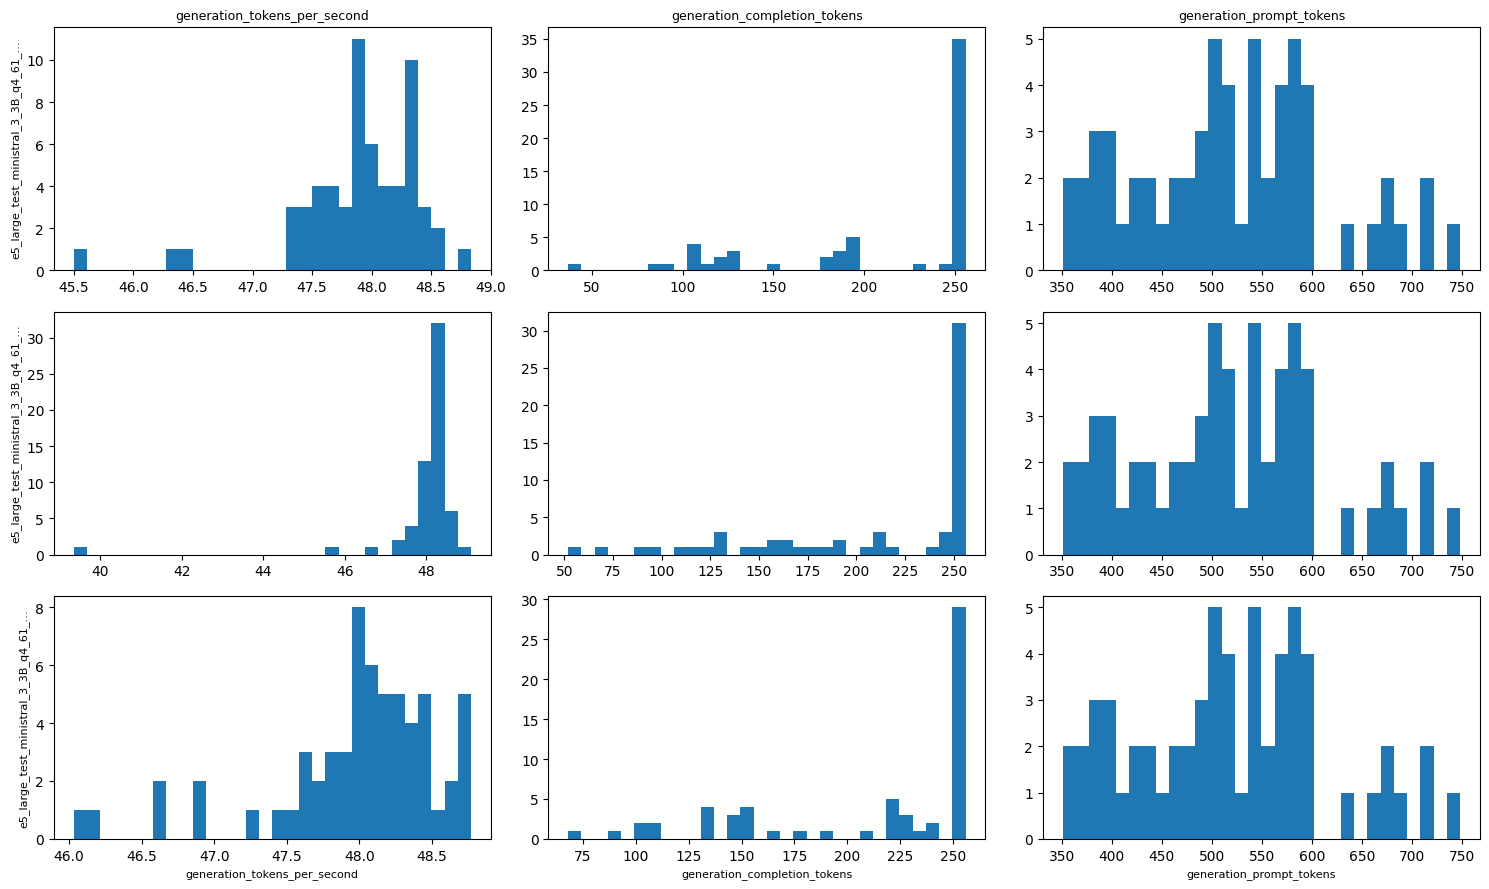

In [30]:
plot_generation_as_hist(df_stable, group_by="session_id", group_order=stable_sessions)

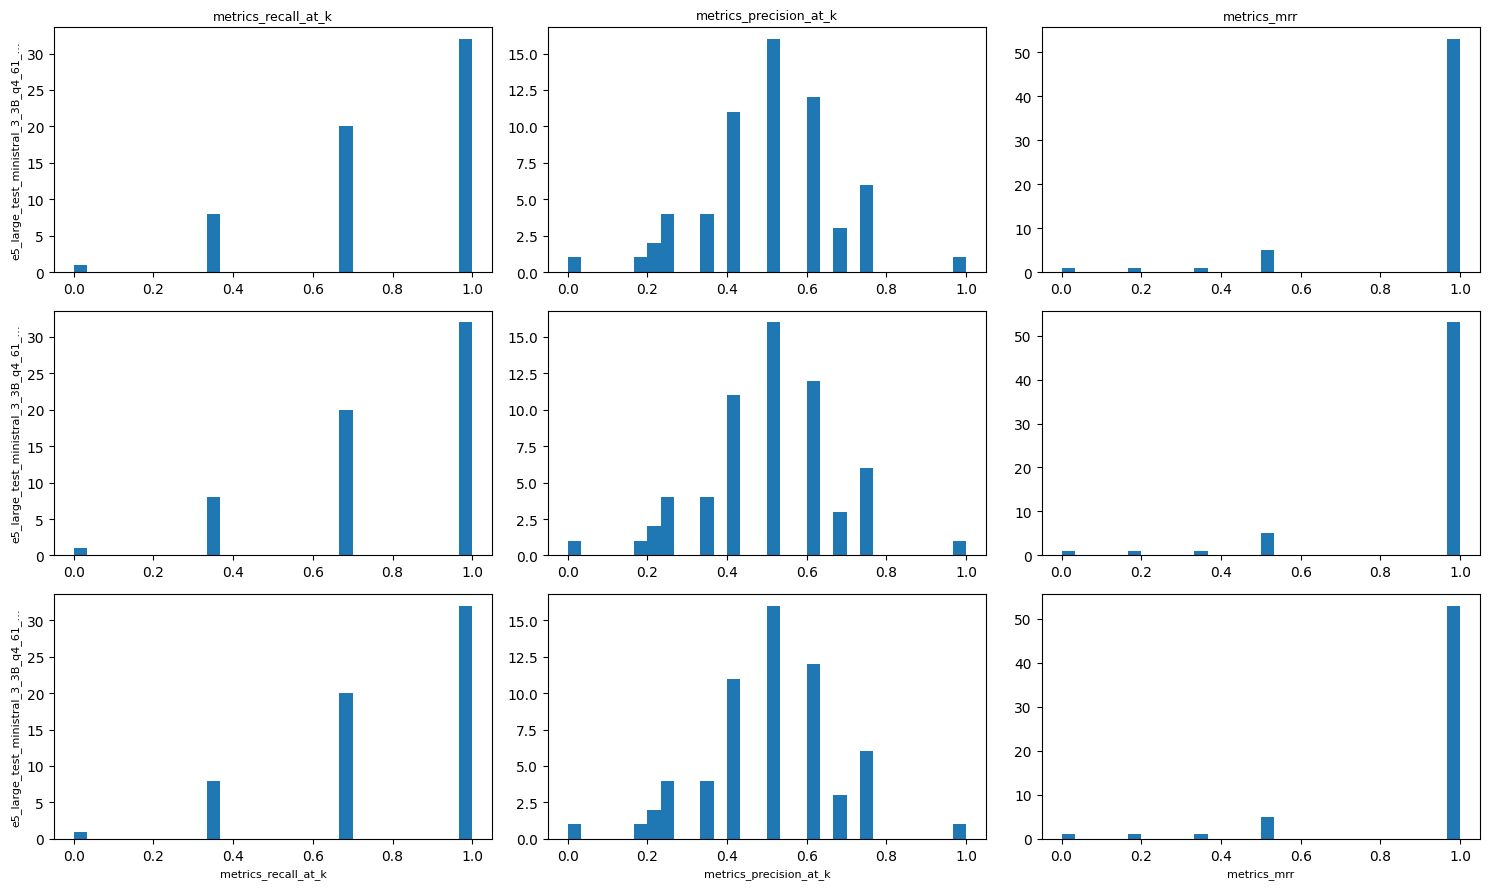

In [31]:
plot_retrieval_as_hist(df_stable, group_by="session_id", group_order=stable_sessions)

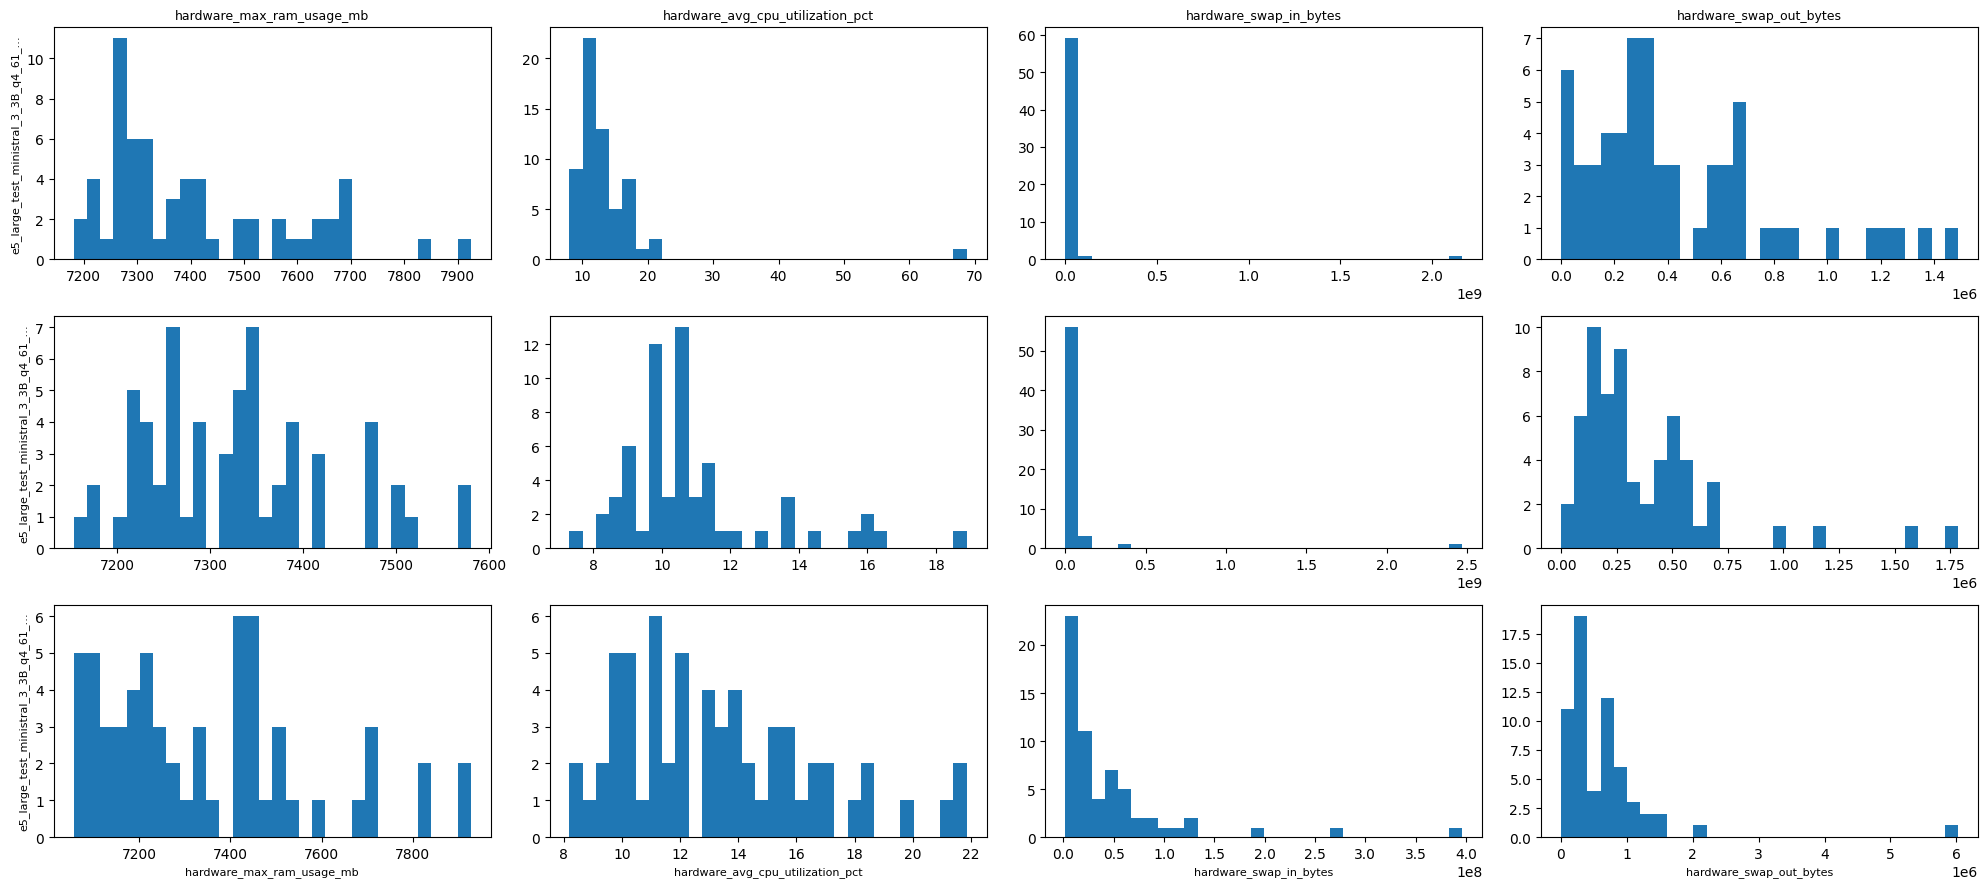

In [32]:
plot_hardware_as_hist(df_stable, group_by="session_id", group_order=stable_sessions)

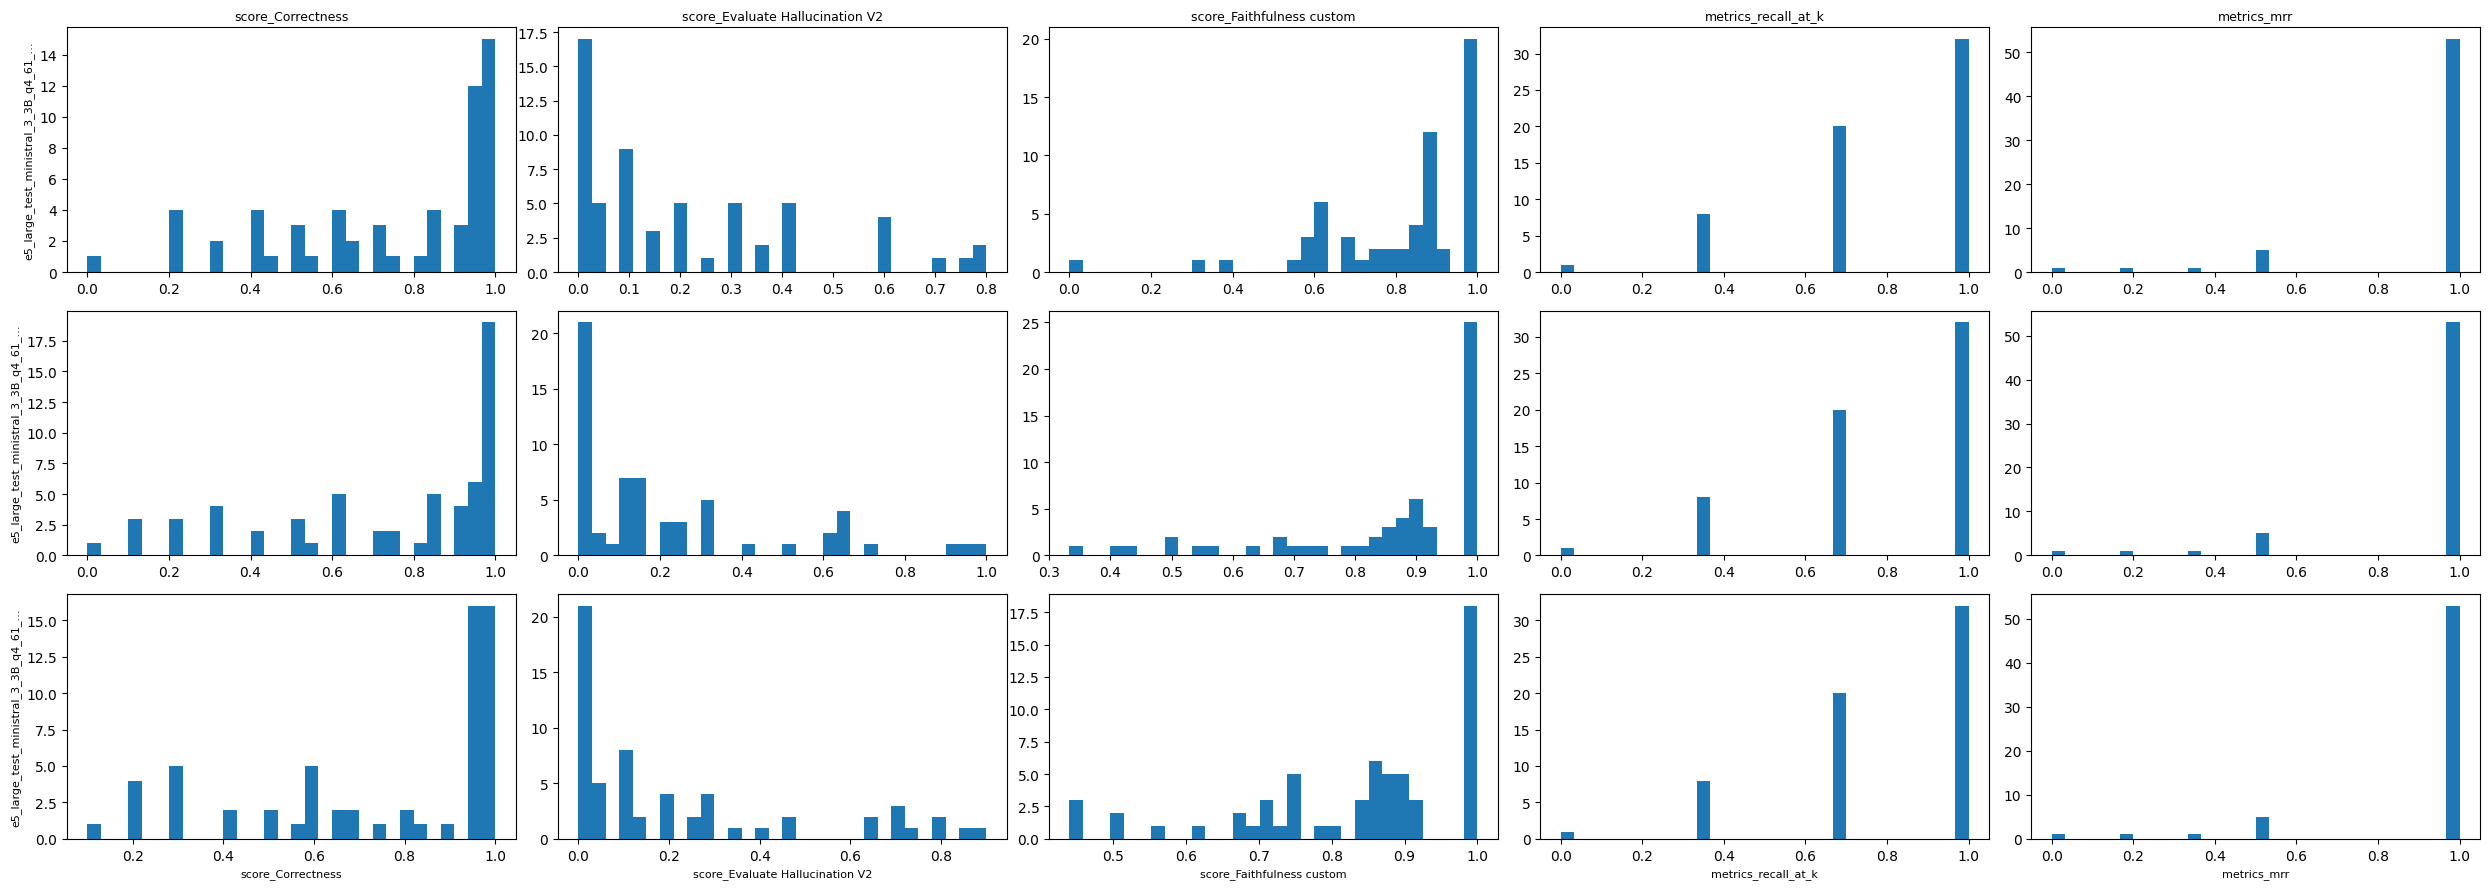

In [33]:
plot_generation_quality_as_hist(df_stable, group_by="session_id", group_order=stable_sessions)

## 3.3  Stats Across Sessions — Line & Multi-line

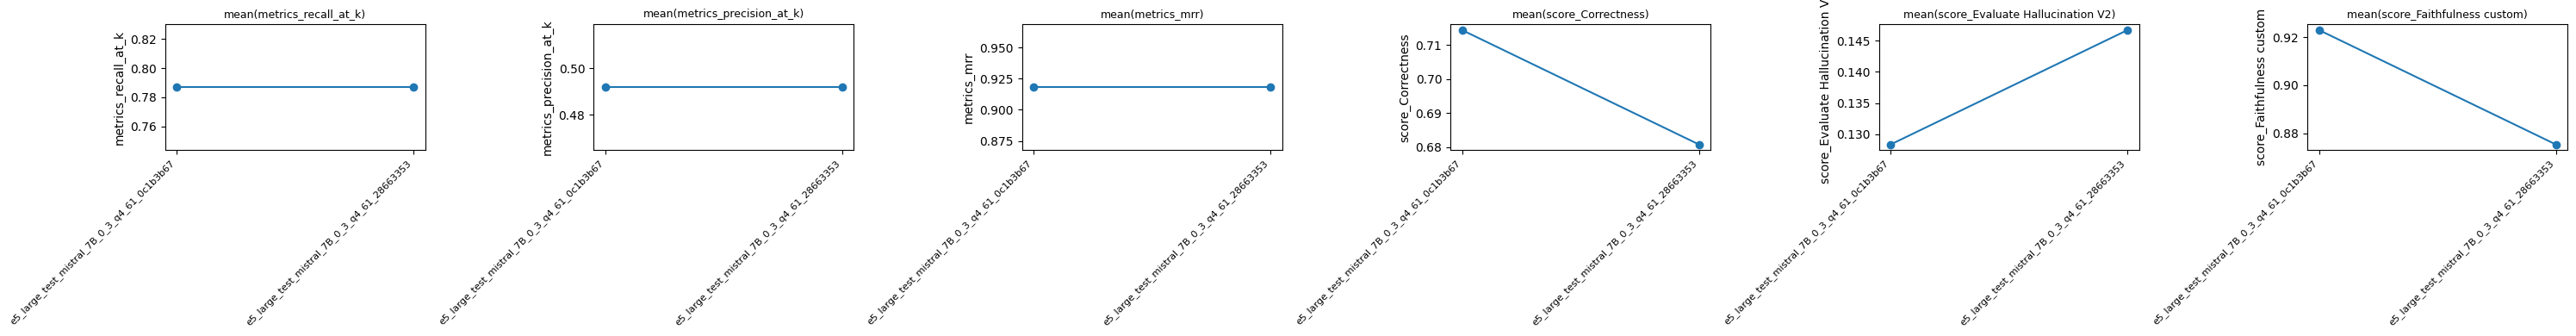

In [79]:
# Mean of each metric across sessions — one subplot per metric
plot_stats_line(df_stable, _present(df_stable, RETRIEVAL_COLS + ["score_Correctness", "score_Evaluate Hallucination V2", "score_Faithfulness custom"]),
                group_by="session_id", group_order=stable_sessions, stat="mean")

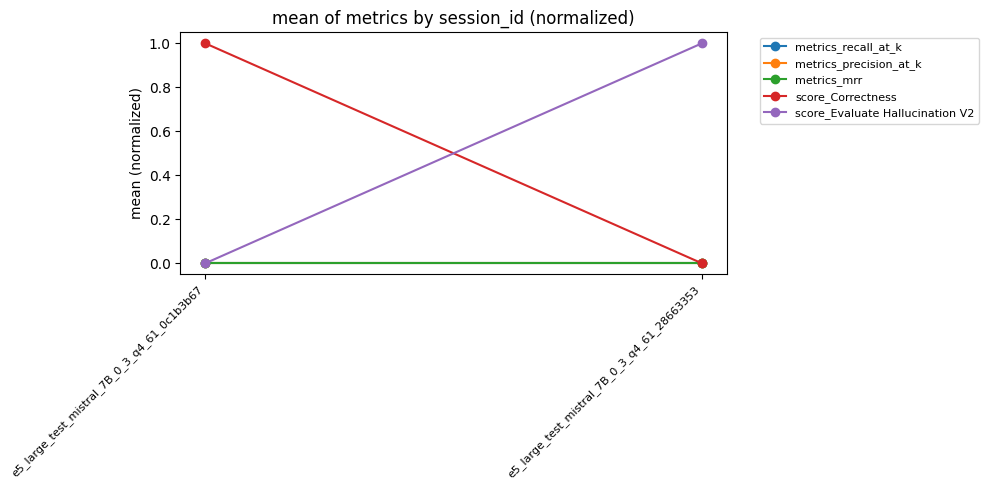

In [80]:
# All quality metrics overlaid in one plot (normalized so different scales are comparable)
plot_stats_multi_line(
    df_stable,
    _present(df_stable, RETRIEVAL_COLS + ["score_Correctness", "score_Evaluate Hallucination V2"]),
    group_by="session_id", group_order=stable_sessions,
    stat="mean", normalize=True,
)

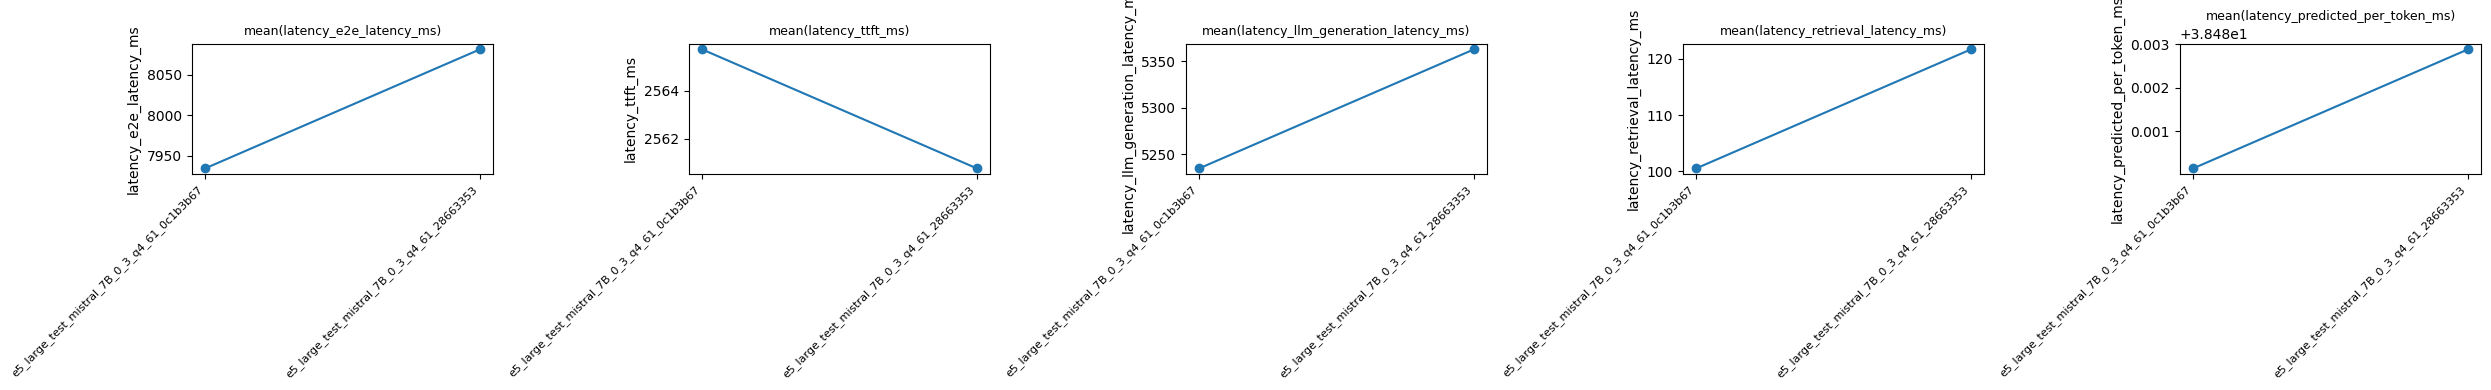

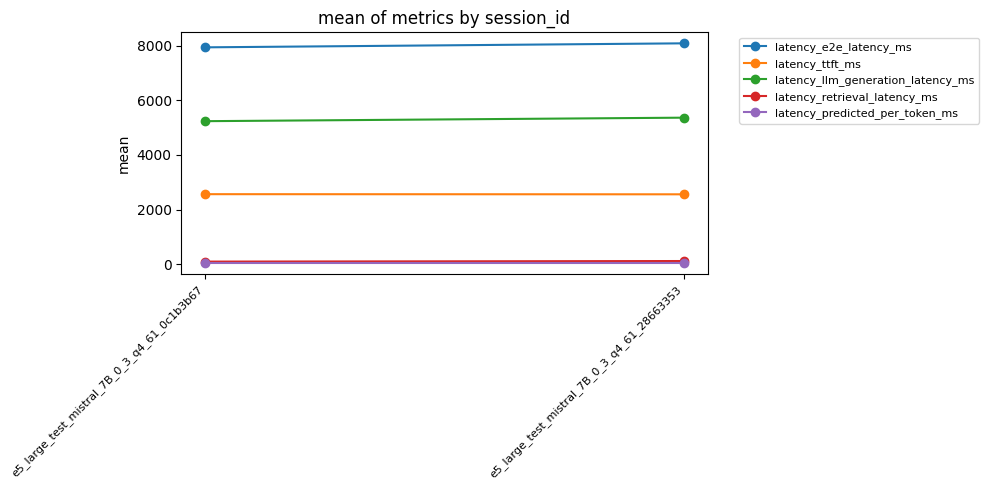

In [81]:
# Latency stability across sessions
plot_stats_line(df_stable, _present(df_stable, LATENCY_COLS),
                group_by="session_id", group_order=stable_sessions, stat="mean")
plot_stats_multi_line(df_stable, _present(df_stable, LATENCY_COLS),
                      group_by="session_id", group_order=stable_sessions,
                      stat="mean", normalize=False)

---
# 4  Per-Session Statistics for a Given Run ID

Descriptive stats (mean, std, median, etc.) broken down by `session_id` within one `run_id`.

In [39]:
# Select the run_id for per-session statistics (can be same as STABILITY_RUN_ID or different)
STATS_RUN_ID = get_run_ids(df_multi)[0]  # replace with a string literal
STATS_RUN_ID = "e5_large_test_ministral_3_8B_q4_61"

df_stats = df_multi[df_multi["run_id"] == STATS_RUN_ID].copy()
stats_sessions = get_session_ids(df_stats)

print(f"Run ID: {STATS_RUN_ID}  |  {len(stats_sessions)} session(s)")

Run ID: e5_large_test_ministral_3_8B_q4_61  |  3 session(s)


## 4.1  Descriptive Statistics Table

In [55]:
display(stats_by_group(df_stats, group_by="session_id"))

latency_ms                        \
                                                 count       mean        std   
session_id                                                                     
e5_large_test_ministral_3_8B_q4_61_5b437b29       61.0  11892.951   2979.902   
e5_large_test_ministral_3_8B_q4_61_6c1db0ad       61.0  14128.180  17528.349   
e5_large_test_ministral_3_8B_q4_61_e4176cee       61.0  12375.279   3226.265   

                                                                       \
                                                min      25%      50%   
session_id                                                              
e5_large_test_ministral_3_8B_q4_61_5b437b29  4093.0   9510.0  13375.0   
e5_large_test_ministral_3_8B_q4_61_6c1db0ad  4951.0   9909.0  13325.0   
e5_large_test_ministral_3_8B_q4_61_e4176cee  4317.0  10256.0  13647.0   

                                                                \
                                                 75%       max   
session_id                                                       
e5_large_test_ministral_3_8B_q4_61_5b437b29  14014.0   16384.0   
e5_large_test_ministral_3_8B_q4_61_6c1db0ad  14253.0  146885.0   
e5_large_test_ministral_3_8B_q4_61_e4176cee  14445.0   20838.0   

                                            latency_ttft_ms            ...  \
                                                      count      mean  ...   
session_id                                                             ...   
e5_large_test_ministral_3_8B_q4_61_5b437b29            61.0  2577.487  ...   
e5_large_test_ministral_3_8B_q4_61_6c1db0ad            61.0  2594.710  ...   
e5_large_test_ministral_3_8B_q4_61_e4176cee            61.0  2617.130  ...   

                                            score_Correctness       \
                                                          75%  max   
session_id                                                           
e5_large_test_ministral_3_8B_q4_61_5b437b29              1.00  1.0   
e5_large_test_ministral_3_8B_q4_61_6c1db0ad              1.00  1.0   
e5_large_test_ministral_3_8B_q4_61_e4176cee              0.95  1.0   

                                            score_Evaluate Hallucination V2  \
                                                                      count   
session_id                                                                    
e5_large_test_ministral_3_8B_q4_61_5b437b29                            61.0   
e5_large_test_ministral_3_8B_q4_61_6c1db0ad                            59.0   
e5_large_test_ministral_3_8B_q4_61_e4176cee                            61.0   

                                                                          \
                                              mean    std  min  25%  50%   
session_id                                                                 
e5_large_test_ministral_3_8B_q4_61_5b437b29  0.154  0.212  0.0  0.0  0.1   
e5_large_test_ministral_3_8B_q4_61_6c1db0ad  0.191  0.235  0.0  0.0  0.1   
e5_large_test_ministral_3_8B_q4_61_e4176cee  0.156  0.237  0.0  0.0  0.1   

                                                         
                                              75%   max  
session_id                                               
e5_large_test_ministral_3_8B_q4_61_5b437b29  0.20  0.95  
e5_large_test_ministral_3_8B_q4_61_6c1db0ad  0.30  0.80  
e5_large_test_ministral_3_8B_q4_61_e4176cee  0.15  0.95  

[3 rows x 168 columns]

## 4.2  Mean per Session — Bar Charts

In [ ]:
plot_stats_bar(df_stats, _present(df_stats, RETRIEVAL_COLS + ["score_Correctness", "score_Evaluate Hallucination V2"]),
               group_by="session_id", group_order=stats_sessions, stat="mean")

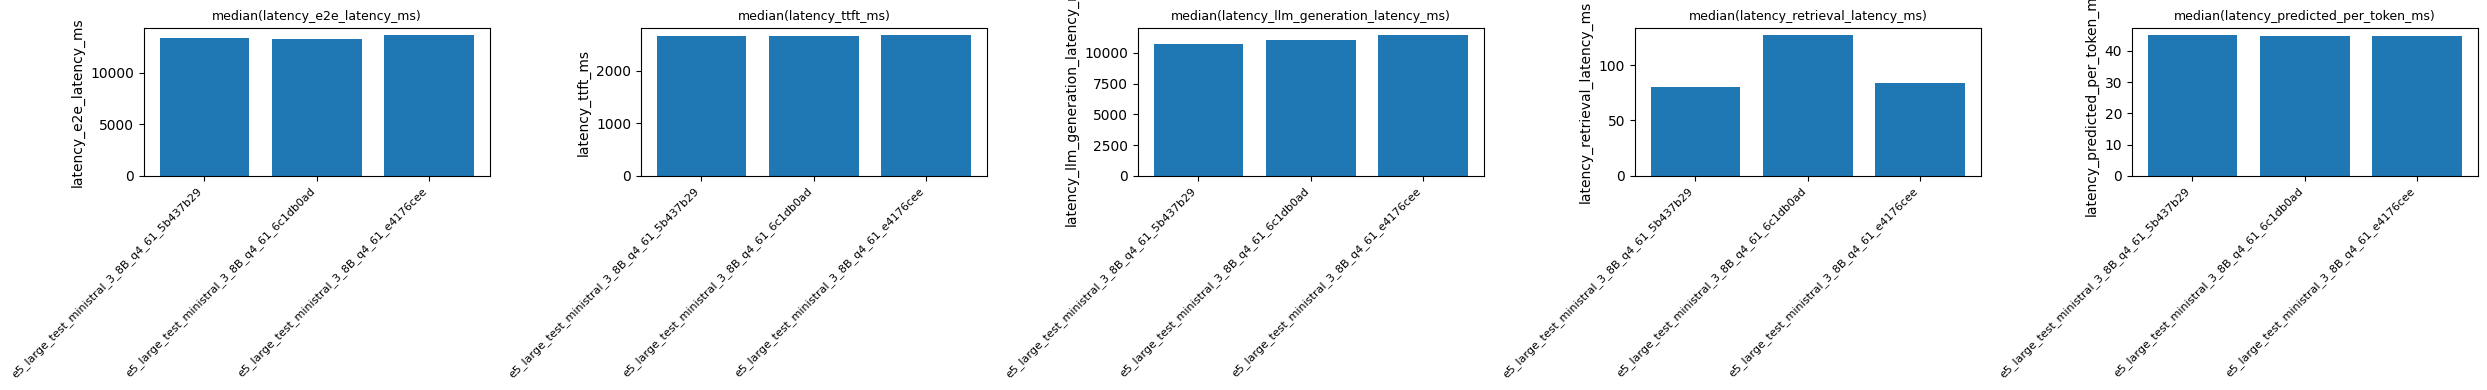

In [60]:
plot_stats_bar(df_stats, _present(df_stats, LATENCY_COLS),
               group_by="session_id", group_order=stats_sessions, stat="median")

## 4.3  Std per Session — Bar Charts (variance across runs)

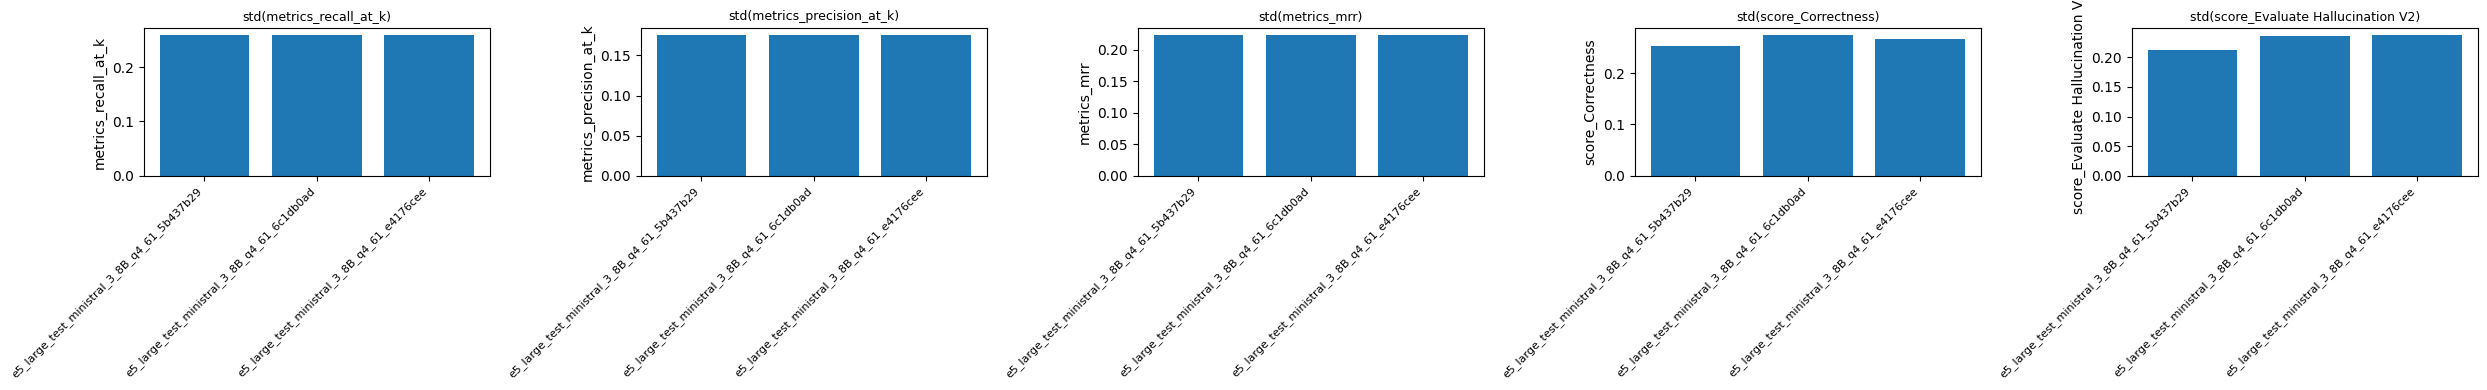

In [40]:
plot_stats_bar(df_stats, _present(df_stats, RETRIEVAL_COLS + ["score_Correctness", "score_Evaluate Hallucination V2"]),
               group_by="session_id", group_order=stats_sessions, stat="std")

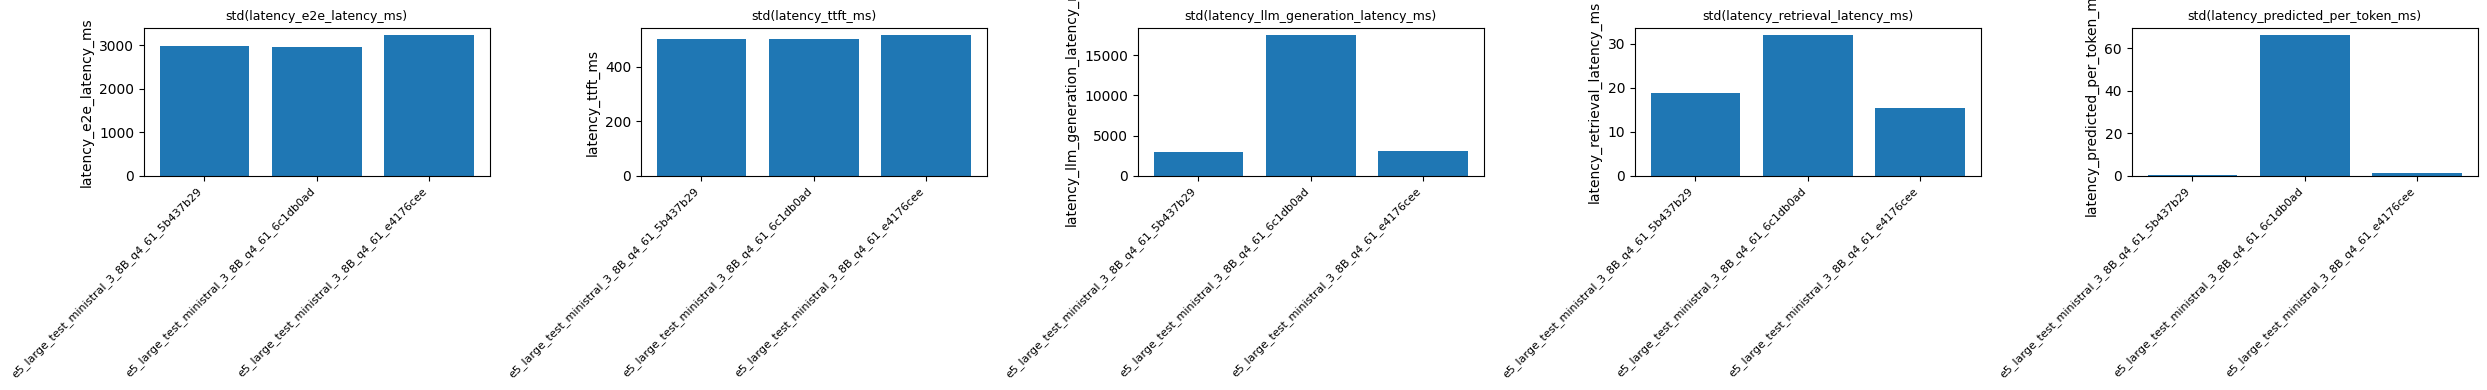

In [41]:
plot_stats_bar(df_stats, _present(df_stats, LATENCY_COLS),
               group_by="session_id", group_order=stats_sessions, stat="std")

## 4.4  Line & Multi-line Stats for One Run ID

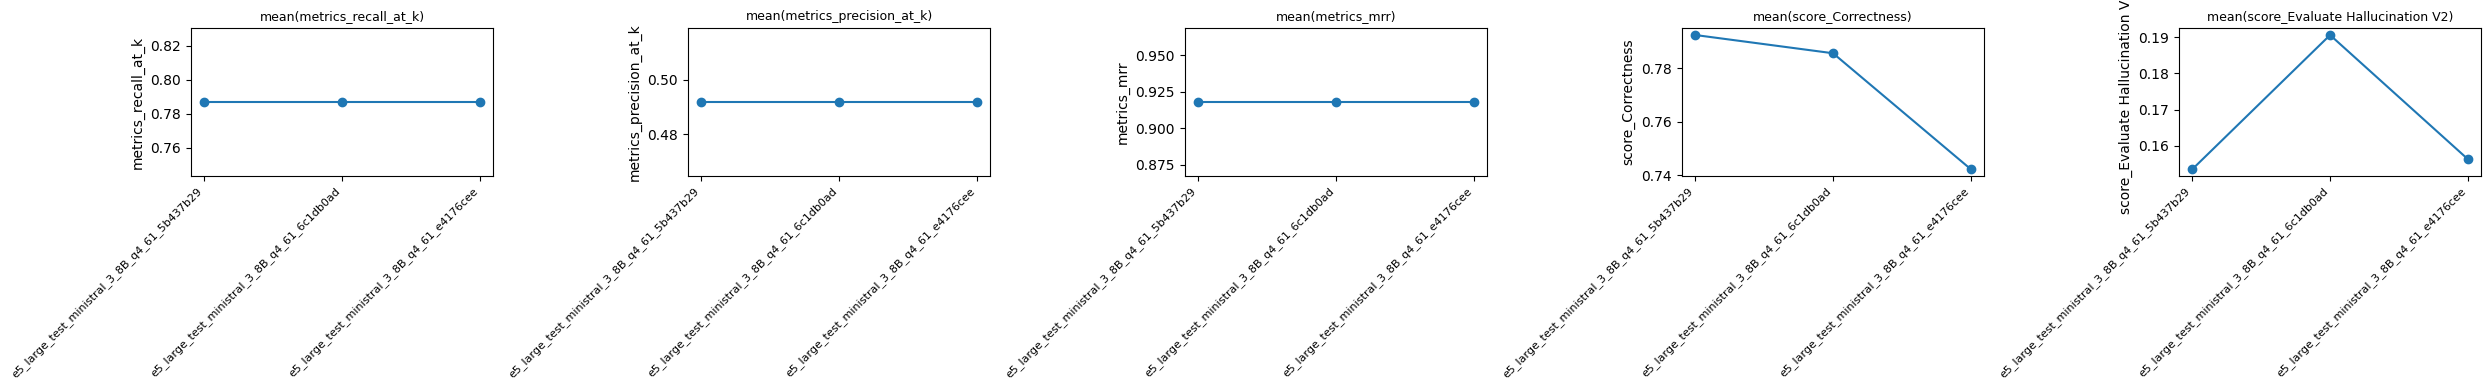

In [42]:
# Per-session mean of quality metrics for the selected run — line per metric
plot_stats_line(df_stats,
                _present(df_stats, RETRIEVAL_COLS + ["score_Correctness", "score_Evaluate Hallucination V2"]),
                group_by="session_id", group_order=stats_sessions, stat="mean")

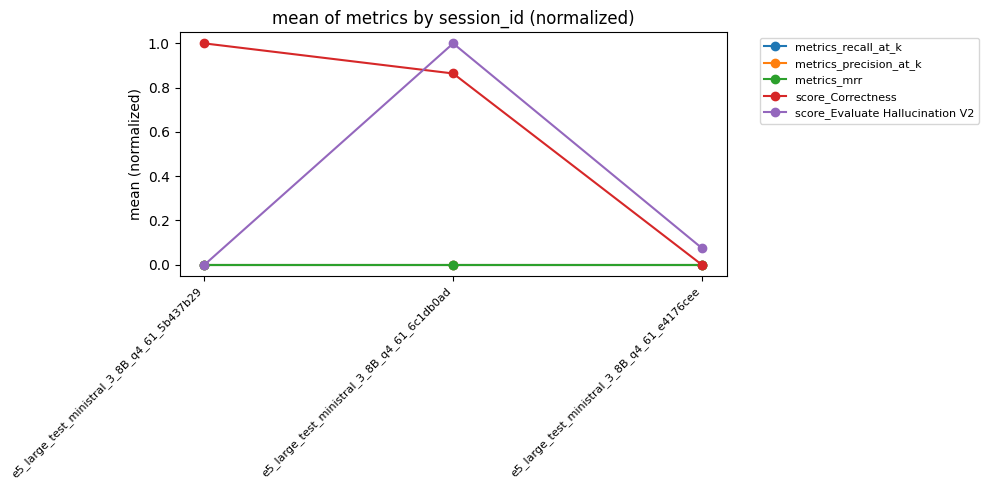

In [43]:
# All quality metrics in one plot — normalized for cross-metric comparison
plot_stats_multi_line(
    df_stats,
    _present(df_stats, RETRIEVAL_COLS + ["score_Correctness", "score_Evaluate Hallucination V2"]),
    group_by="session_id", group_order=stats_sessions,
    stat="mean", normalize=True,
)

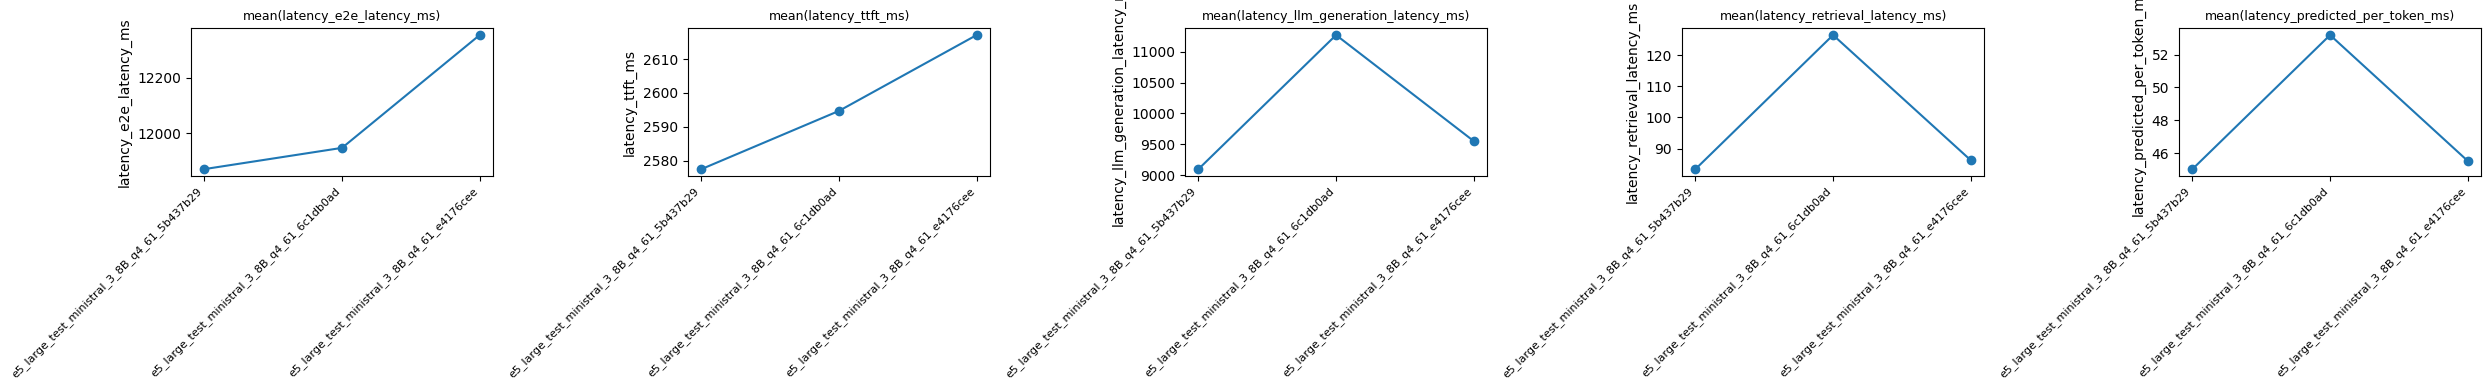

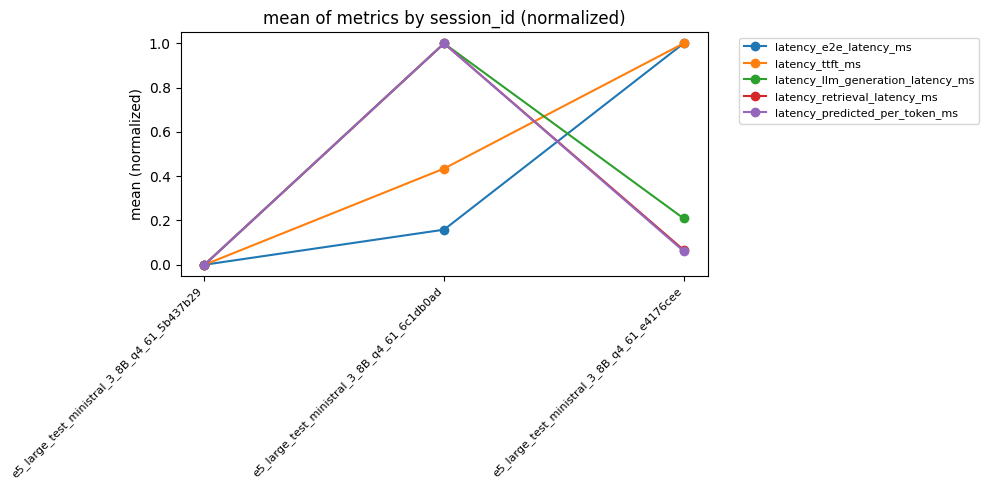

In [44]:
# Latency line plots
plot_stats_line(df_stats, _present(df_stats, LATENCY_COLS),
                group_by="session_id", group_order=stats_sessions, stat="mean")
plot_stats_multi_line(df_stats, _present(df_stats, LATENCY_COLS),
                      group_by="session_id", group_order=stats_sessions,
                      stat="mean", normalize=True)